# Plot Figure 2

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

### Load Data:

In [48]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked_fscapresence.pkl', 'rb'))

In [37]:
sierras = gpd.read_file('../../data/misc/sierra_simplified.geojson')

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth:

In [6]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [8]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [9]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [10]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [26]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [13]:
mask_da = mask.astype(np.int32)

In [27]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds.where(mask)

In [42]:
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs.where(mask)

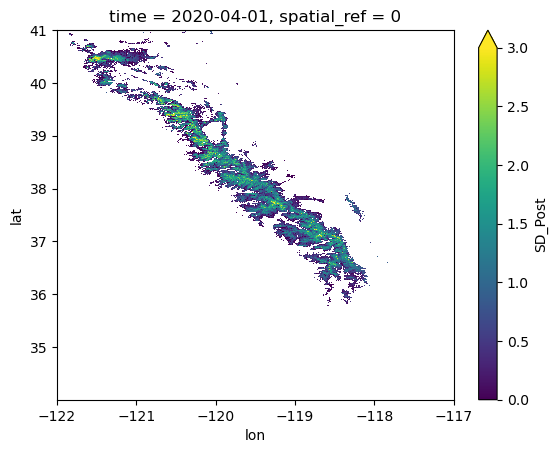

In [81]:
swe_sca_ds_roi.SD_Post.sel(time='2020-04-01').plot(vmax=3)

In [28]:
# 5. Compute spatial median
median_sd = swe_sca_ds_roi.median(dim=('lat', 'lon'), skipna=True).compute()

In [43]:
median_sd_allyrs = swe_sca_ds_allyrs_roi.median(dim=('lat', 'lon'), skipna=True).compute()

In [13]:
swe_sca_ds

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, lat: 1575, lon: 1125)
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [ ]:
swe_sca_ds = swe_sca_ds.rename({'lat':'y','lon':'x'})
swe_sca_ds_sierras = swe_sca_ds.rio.clip(sierras.geometry)
median_sca = swe_sca_ds_sierras.SCA_Post.median(dim=('y', 'x'), skipna=True)

In [ ]:
swe_sca_ds_roi = swe_sca_ds_roi.rename({'lat':'y','lon':'x'})
median_sca = swe_sca_ds_roi.SCA_Post.median(dim=('y', 'x'), skipna=True).compute()

In [44]:
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_roi.rename({'lat':'y','lon':'x'})
median_sca_allyrs_roi = swe_sca_ds_allyrs_roi.SCA_Post.median(dim=('y', 'x'), skipna=True).compute()

SCA values where SD = 0:
  Min: 0.000
  Max: 0.310
  Mean: 0.005
  Median: 0.000
  Count: 4900


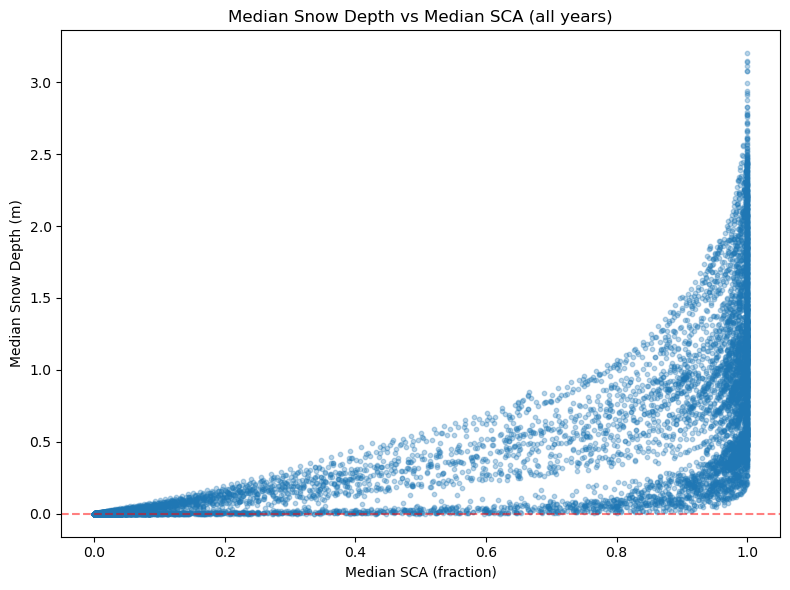

In [46]:
# Plot median SD vs median SCA to find SCA threshold when SD = 0
import matplotlib.pyplot as plt

# Align the time coordinates
sd_values = median_sd_allyrs.SD_Post.values
sca_values = median_sca_allyrs_roi.values

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sca_values, sd_values, alpha=0.3, s=10)
ax.set_xlabel('Median SCA (fraction)')
ax.set_ylabel('Median Snow Depth (m)')
ax.set_title('Median Snow Depth vs Median SCA (all years)')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='SD = 0')

# Find SCA values where SD is 0 or very close to 0
zero_sd_mask = sd_values == 0
if zero_sd_mask.any():
    sca_at_zero_sd = sca_values[zero_sd_mask]
    print(f"SCA values where SD = 0:")
    print(f"  Min: {sca_at_zero_sd.min():.3f}")
    print(f"  Max: {sca_at_zero_sd.max():.3f}")
    print(f"  Mean: {sca_at_zero_sd.mean():.3f}")
    print(f"  Median: {np.median(sca_at_zero_sd):.3f}")
    print(f"  Count: {len(sca_at_zero_sd)}")

plt.tight_layout()
plt.show()

In [47]:
# Save median SD and SCA time series to files
import os

output_dir = '/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/data/reanalysis/spatial_median_timeseries'
os.makedirs(output_dir, exist_ok=True)

# Save median snow depth (all years)
median_sd_allyrs.to_netcdf(os.path.join(output_dir, 'median_sd_allyrs.nc'))

# Save median SCA (all years, ROI)
median_sca_allyrs_roi.to_netcdf(os.path.join(output_dir, 'median_sca_allyrs_roi.nc'))

print(f"Saved to: {output_dir}")

Saved to: ../../swe_reanalysis_pca/data/download/data/spatial_median_timeseries


In [ ]:
# 5. Compute spatial median


In [27]:
median_sca_masked = swe_sca_ds_sierras.SCA_Post.where(swe_sca_ds_sierras.SCA_Post > 0).median(dim=('y','x'))

In [30]:
# Pixels where the maximum SCA across all time is > 0
ever_snow_mask = swe_sca_ds_sierras.SCA_Post.max(dim='time') > 0

median_sca_masked = swe_sca_ds_sierras.SCA_Post.where(ever_snow_mask).median(dim=('y','x'))

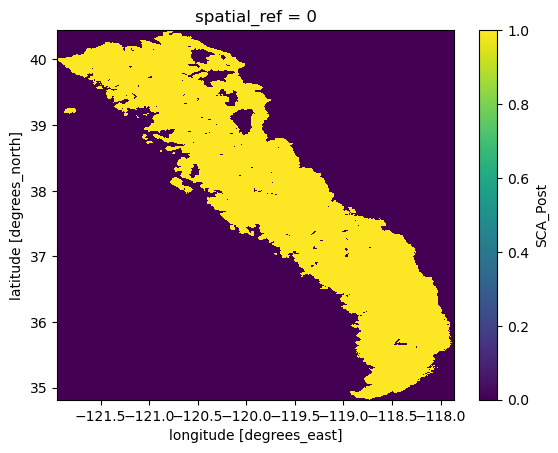

In [33]:
ever_snow_mask.plot()

In [18]:
median_sca

<xarray.DataArray 'SCA_Post' (time: 1096)> Size: 4kB
dask.array<nanmedian, shape=(1096,), dtype=float32, chunksize=(28,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0

In [28]:
median_sca_masked

<xarray.DataArray 'SCA_Post' (time: 1096)> Size: 4kB
dask.array<nanmedian, shape=(1096,), dtype=float32, chunksize=(28,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0

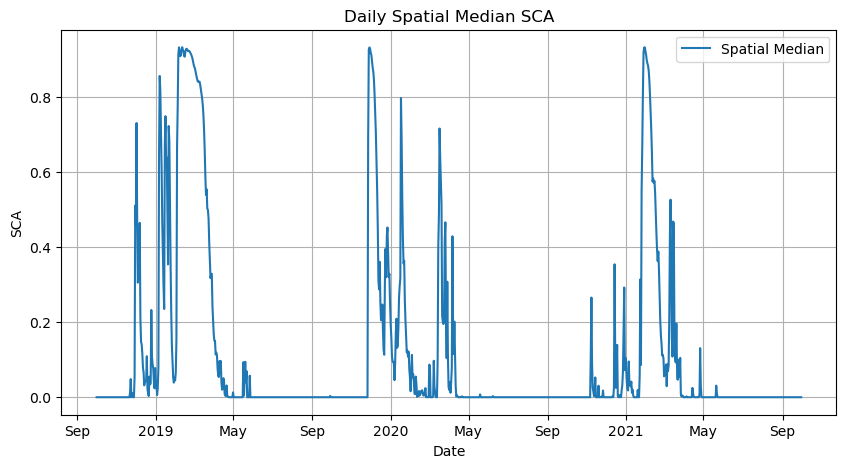

In [20]:
# 6. Plot
plt.figure(figsize=(10,5))
median_sca.plot(label='Spatial Median')
plt.title('Daily Spatial Median SCA')
plt.xlabel('Date')
plt.ylabel('SCA')
plt.grid(True)
plt.legend()
plt.show()

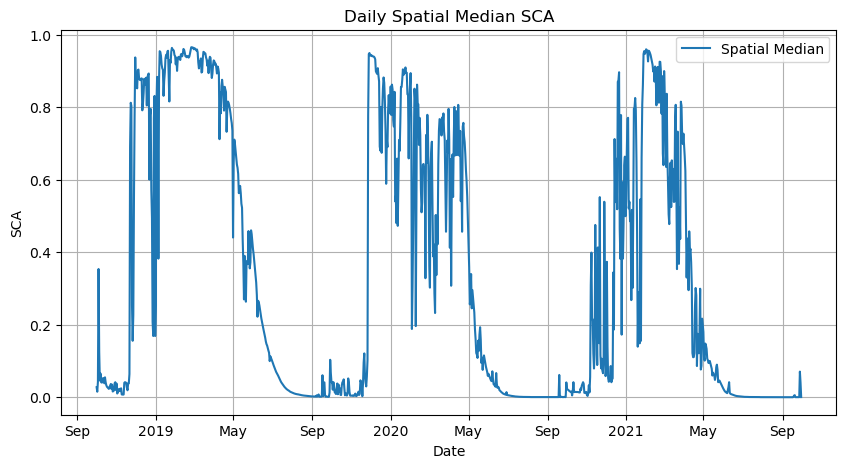

In [29]:
# 6. Plot
plt.figure(figsize=(10,5))
median_sca_masked.plot(label='Spatial Median')
plt.title('Daily Spatial Median SCA')
plt.xlabel('Date')
plt.ylabel('SCA')
plt.grid(True)
plt.legend()
plt.show()

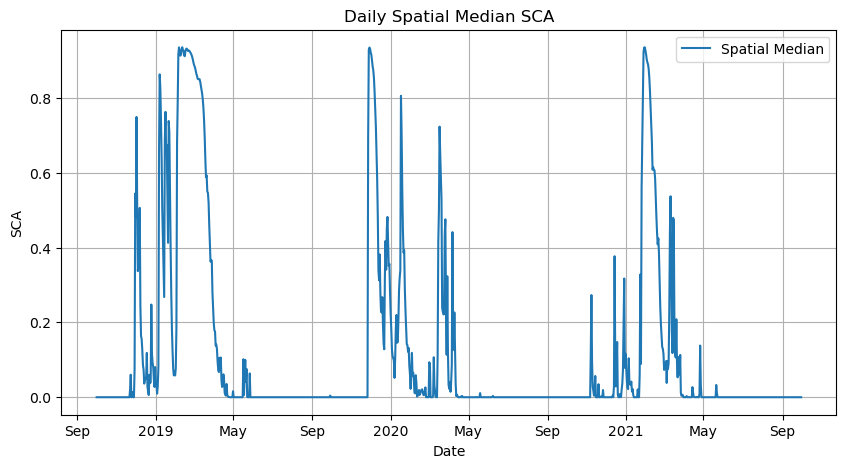

In [31]:
# 6. Plot
plt.figure(figsize=(10,5))
median_sca_masked.plot(label='Spatial Median')
plt.title('Daily Spatial Median SCA')
plt.xlabel('Date')
plt.ylabel('SCA')
plt.grid(True)
plt.legend()
plt.show()

In [48]:
ever_snow_mask

<xarray.DataArray 'SCA_Post' (y: 1267, x: 919)> Size: 1MB
dask.array<any-aggregate, shape=(1267, 919), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B 0

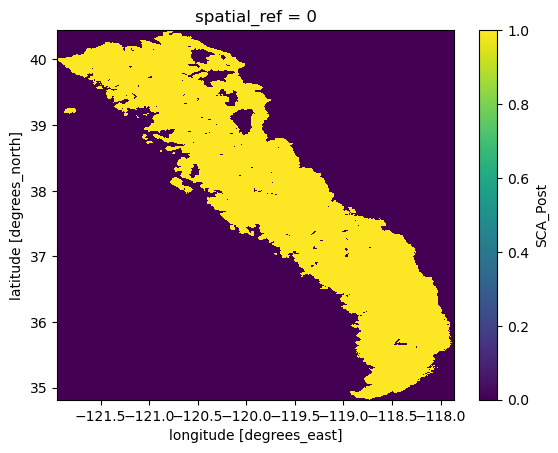

In [49]:
ever_snow_mask.plot()

In [34]:
import numpy as np

# Grid spacing in degrees
dx = abs(float(swe_sca_ds_sierras.x[1] - swe_sca_ds_sierras.x[0]))
dy = abs(float(swe_sca_ds_sierras.y[1] - swe_sca_ds_sierras.y[0]))

# Calculate cell area accounting for latitude (in m²)
R = 6371000  # Earth radius in meters
lat = swe_sca_ds_sierras.y  # latitude values

# Cell area varies with latitude: width shrinks toward poles
# Area = R² * Δlon * (sin(lat + Δlat/2) - sin(lat - Δlat/2))
# Simplified for small cells: Area ≈ R² * cos(lat) * Δlon * Δlat (all in radians)
cell_area = (R ** 2) * np.cos(np.deg2rad(lat)) * np.deg2rad(dx) * np.deg2rad(dy)

# Create mask for pixels that have snow at some point
ever_snow_mask = (swe_sca_ds_sierras.SCA_Post > 0).any(dim='time')

# Calculate fixed total area of the masked region
# cell_area is 1D (varies with y/lat), need to broadcast and sum where mask is True
total_area_fixed = (cell_area * ever_snow_mask).sum().values  # in m²

print(f"Total area of snow-covered region: {total_area_fixed / 1e6:.2f} km²")

# Apply mask to SCA
sca_masked = swe_sca_ds_sierras.SCA_Post.where(ever_snow_mask)

# Calculate area-weighted mean SCA for each day
# Sum(SCA * cell_area) / total_area
mean_sca_area_weighted = (sca_masked * cell_area).sum(dim=('y', 'x'), skipna=True) / total_area_fixed

Total area of snow-covered region: 61326.98 km²


In [40]:
swe_sca_ds_allyrs

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, lat: 1575, lon: 1125)
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [42]:
# clip all years to the sieras:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'lat': 'y', 'lon': 'x'})
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

# Apply mask to SCA
sca_masked_all_years = swe_sca_ds_allyrs_sierras.SCA_Post.where(ever_snow_mask)

# Calculate area-weighted mean SCA for each day
# Sum(SCA * cell_area) / total_area
mean_sca_area_weighted_all_years = (sca_masked_all_years * cell_area).sum(dim=('y', 'x'), skipna=True) / total_area_fixed

In [35]:
mean_sca_area_weighted

<xarray.DataArray (time: 1096)> Size: 9kB
dask.array<truediv, shape=(1096,), dtype=float64, chunksize=(61,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0

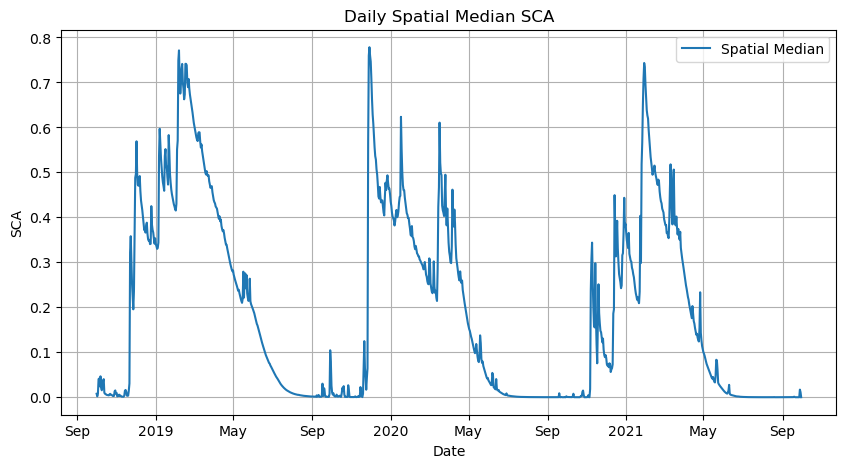

In [36]:
# 6. Plot
plt.figure(figsize=(10,5))
mean_sca_area_weighted.plot(label='Spatial Median')
plt.title('Daily Spatial Median SCA')
plt.xlabel('Date')
plt.ylabel('SCA')
plt.grid(True)
plt.legend()
plt.show()

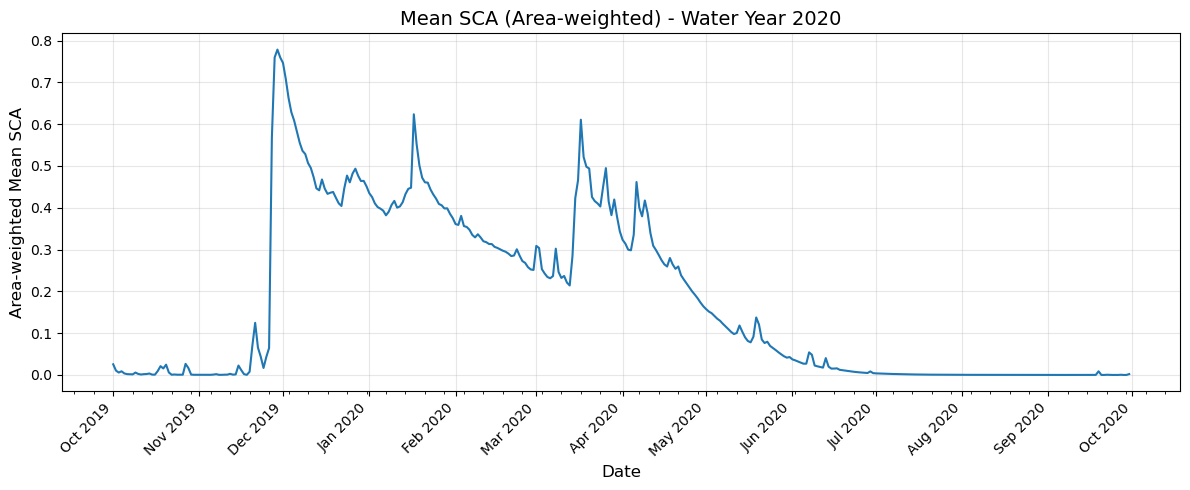

In [ ]:
import matplotlib.dates as mdates

# Filter to water year 2020 (October 1, 2019 to September 30, 2020)
wy2020_start = '2019-10-01'
wy2020_end = '2020-09-30'

# mean_sca_wy2020 = mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end)).plot(ax=ax)

# Set x-axis to show monthly ticks with more detail
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Minor ticks at weeks

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Area-weighted Mean SCA', fontsize=12)
ax.set_title('Mean SCA (Area-weighted) - Water Year 2020', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

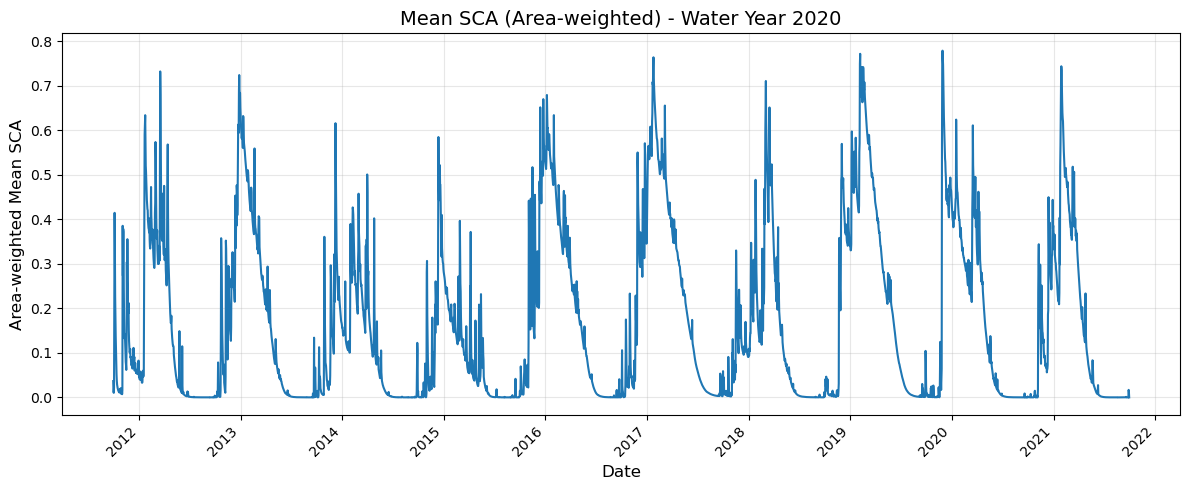

In [43]:
import matplotlib.dates as mdates

# Filter to water year 2020 (October 1, 2019 to September 30, 2020)
date_start = '2011-10-01'
date_end = '2021-09-30'

# mean_sca_wy2020 = mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
mean_sca_area_weighted_all_years.sel(time=slice(date_start, date_end)).plot(ax=ax)

# Set x-axis to show monthly ticks with more detail
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Minor ticks at weeks

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Area-weighted Mean SCA', fontsize=12)
ax.set_title('Mean SCA (Area-weighted) - Water Year 2020', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

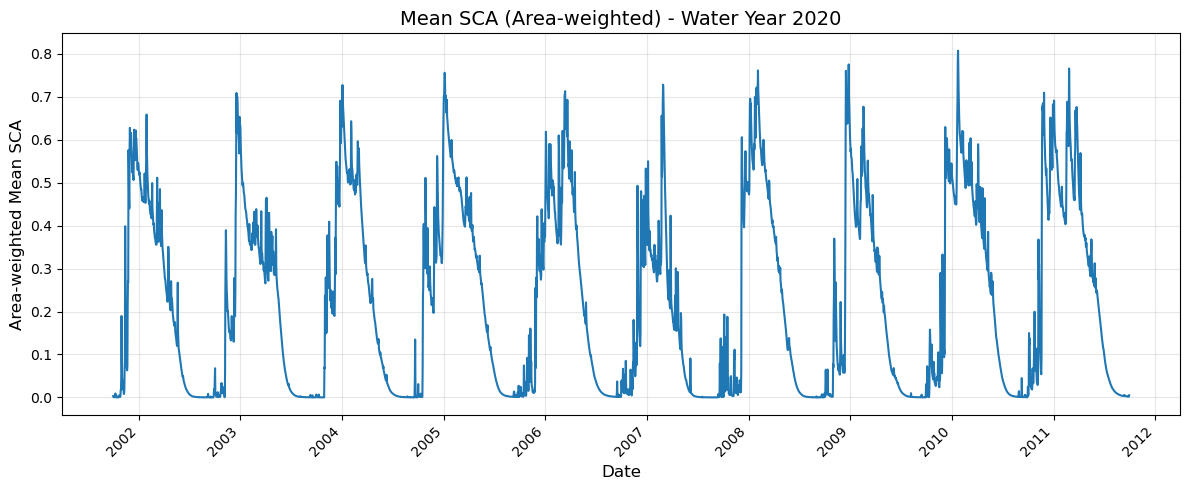

In [44]:
# import matplotlib.dates as mdates

# Filter to water year 2020 (October 1, 2019 to September 30, 2020)
date_start = '2001-10-01'
date_end = '2011-09-30'

# mean_sca_wy2020 = mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
mean_sca_area_weighted_all_years.sel(time=slice(date_start, date_end)).plot(ax=ax)

# Set x-axis to show monthly ticks with more detail
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Minor ticks at weeks

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Area-weighted Mean SCA', fontsize=12)
ax.set_title('Mean SCA (Area-weighted) - Water Year 2020', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

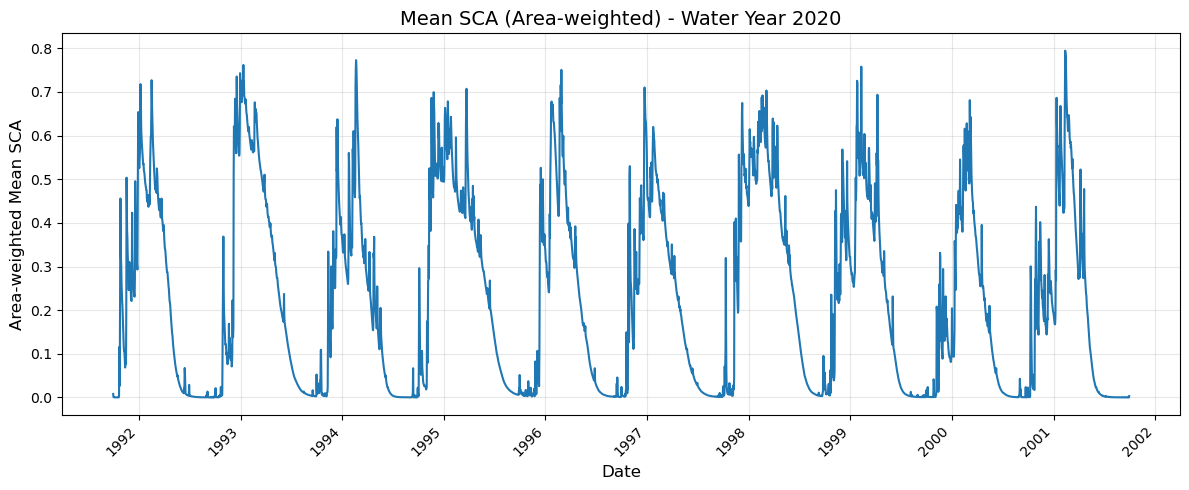

In [45]:
# import matplotlib.dates as mdates

# Filter to water year 2020 (October 1, 2019 to September 30, 2020)
date_start = '1991-10-01'
date_end = '2001-09-30'

# mean_sca_wy2020 = mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
mean_sca_area_weighted_all_years.sel(time=slice(date_start, date_end)).plot(ax=ax)

# Set x-axis to show monthly ticks with more detail
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Minor ticks at weeks

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Area-weighted Mean SCA', fontsize=12)
ax.set_title('Mean SCA (Area-weighted) - Water Year 2020', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

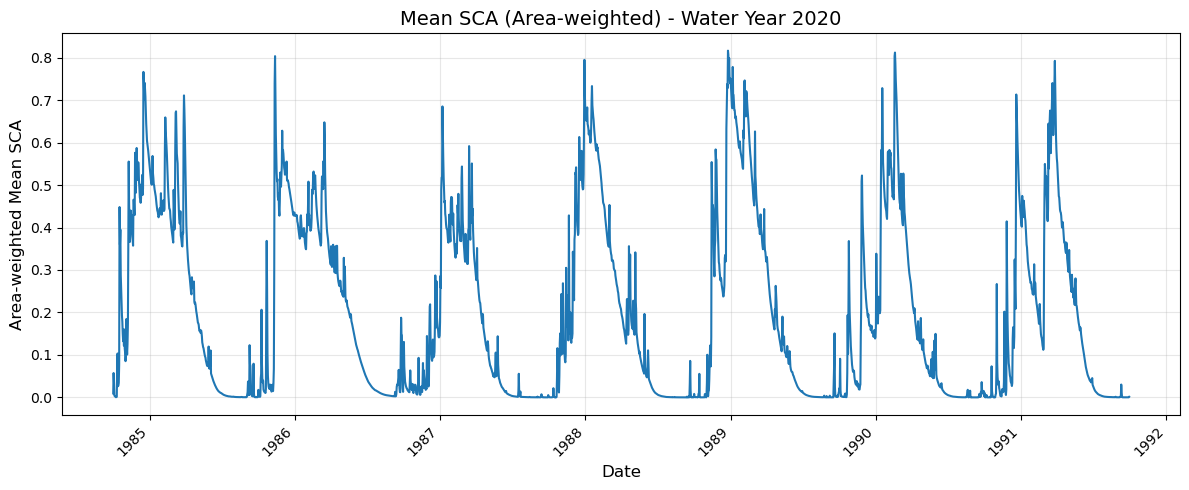

In [46]:
# import matplotlib.dates as mdates

# Filter to water year 2020 (October 1, 2019 to September 30, 2020)
date_start = '1984-10-01'
date_end = '1991-09-30'

# mean_sca_wy2020 = mean_sca_area_weighted.sel(time=slice(wy2020_start, wy2020_end))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
mean_sca_area_weighted_all_years.sel(time=slice(date_start, date_end)).plot(ax=ax)

# Set x-axis to show monthly ticks with more detail
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Minor ticks at weeks

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Area-weighted Mean SCA', fontsize=12)
ax.set_title('Mean SCA (Area-weighted) - Water Year 2020', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

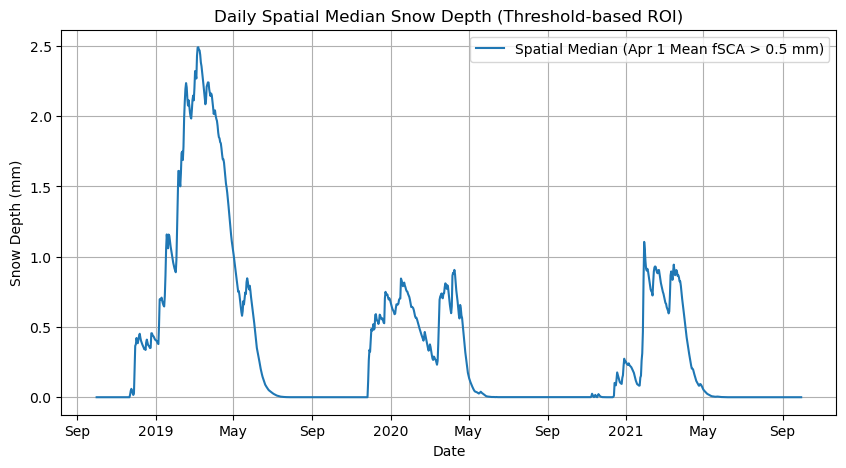

In [79]:
# 6. Plot
plt.figure(figsize=(10,5))
median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')
plt.title('Daily Spatial Median Snow Depth (Threshold-based ROI)')
plt.xlabel('Date')
plt.ylabel('Snow Depth (mm)')
plt.grid(True)
plt.legend()
plt.show()

### Sample xarray mask for the icesat2 points:

In [53]:
swe_sca_ds

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, lat: 1575, lon: 1125)
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [55]:
mask

<xarray.DataArray 'SCA_Post' (lat: 1575, lon: 1125)> Size: 2MB
dask.array<gt, shape=(1575, 1125), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0

In [18]:
latitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.x.values, dims="points")

In [19]:
#atl06sr_gdf['mask'] = np.nan

sampled_mask = mask_da.sel(lat=latitudes, lon=longitudes, method='nearest').values

In [20]:
atl06sr_gdf['mask'] = sampled_mask

In [21]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [19]:
atl06sr_gdf['acqdate_dt']

time_ns
2018-10-14 11:40:32.487777792   2018-10-14
2018-10-14 11:40:32.490599168   2018-10-14
2018-10-14 11:40:32.493418752   2018-10-14
2018-10-14 11:40:32.496237568   2018-10-14
2018-10-14 11:40:32.499053056   2018-10-14
                                   ...    
2021-09-30 07:56:05.208622336   2021-09-30
2021-09-30 07:56:05.211433728   2021-09-30
2021-09-30 07:56:05.214239488   2021-09-30
2021-09-30 07:56:05.217039872   2021-09-30
2021-09-30 07:56:05.219838720   2021-09-30
Name: acqdate_dt, Length: 4672860, dtype: datetime64[ns]

<Axes: >

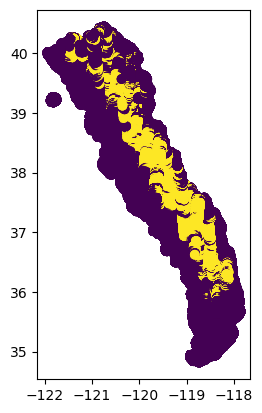

In [25]:
atl06sr_gdf.plot(column='mask')

### Subsest the ICESat-2 data by snow cover and slope to calculate sample size:

In [49]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20)]

In [50]:
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [248]:
atl06sr_gdf_snowy

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,acqdate,reanalysis_swe,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,dif_plus,offset_sd,mask,acqdate_dt,n
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:33.097217024,0.0,1.0,0,2139.365493,6,30.952135,30,24,14.159952,158913789952,...,2018-10-14,0.0,0.0,0.0,4.165757,4.220486,4.220486,1,2018-10-14,5544
2018-10-14 11:40:33.100024576,0.0,1.0,0,2151.848519,6,33.023067,30,22,16.783373,158913789952,...,2018-10-14,0.0,0.0,0.0,3.708366,3.763094,3.763094,1,2018-10-14,5544
2018-10-14 11:40:33.102834176,0.0,1.0,0,2165.369876,6,33.457503,30,11,14.611403,158913789952,...,2018-10-14,0.0,0.0,0.0,2.220212,2.274940,2.274940,1,2018-10-14,5544
2018-10-14 11:40:33.122541824,0.0,1.0,0,2240.212942,6,31.350461,30,11,14.774078,158913789952,...,2018-10-14,0.0,0.0,0.0,0.844187,0.898915,0.898915,1,2018-10-14,5544
2018-10-14 11:40:33.125364992,0.0,1.0,0,2251.848530,6,31.454143,30,13,14.970673,158913789952,...,2018-10-14,0.0,0.0,0.0,0.820904,0.875633,0.875633,1,2018-10-14,5544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:55:53.504230400,0.0,1.0,0,2197.387624,6,30.763602,20,12,11.975057,94489280512,...,2021-09-30,0.0,0.0,0.0,6.951732,7.006460,7.006460,1,2021-09-30,5392
2021-09-30 07:55:53.507028992,0.0,1.0,0,2191.091191,6,28.240192,20,10,11.807220,94489280512,...,2021-09-30,0.0,0.0,0.0,4.103389,4.158118,4.158118,1,2021-09-30,5392
2021-09-30 07:55:53.625182720,0.0,1.0,0,2215.105352,6,29.171046,20,12,5.823441,94489280512,...,2021-09-30,0.0,0.0,0.0,-0.351202,-0.296473,-0.296473,1,2021-09-30,5392


### Repeat using fsca instead of set area:

In [20]:
atl06sr_gdf_fsca_9 = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20)]

In [21]:
atl06sr_gdf_fsca_9['n'] = atl06sr_gdf_fsca_9.groupby('acqdate')['acqdate'].transform('count')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Explore the medians on acquisition dates to select dates for inset plots:

In [20]:
medians_both = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['n']>100), ['icesat2_3dep_dif', 'reanalysis_sd','acqdate']].dropna().groupby('acqdate').median()

In [21]:
medians_both['date'] = pd.to_datetime(medians_both.index)

In [ ]:

# Create the base chart
base = alt.Chart(medians_both).encode(
    x=alt.X('date:T', axis=alt.Axis(title='Date')),
    y=alt.Y('reanalysis_sd:Q', axis=alt.Axis(title='Reanalysis Snow Depth (m)'))
)

# Create the line chart
line = base.mark_point().encode(
    tooltip=[alt.Tooltip('date:T', title='Date'), alt.Tooltip('reanalysis_sd:Q', title='Reanalysis Snow Depth (m)')]
)

# Add interactive selection for zooming and panning
chart = line.interactive()

# Display the chart
chart

alt.Chart(...)

In [14]:
large_dates = ['2019-03-08', '2020-04-11', '2021-03-13']
small_dates = ['2019-04-15', '2020-04-19', '2021-03-17']
weird_dates = ['2020-05-18', '2021-03-05','2021-08-12', '2021-08-16']
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01'] #'2021-01-29'
alt_highlight_dates = pd.to_datetime(['2021-03-17','2021-04-01', '2021-04-07','2021-04-11'])

In [ ]:
medians_both['date']

acqdate
2018-10-14   2018-10-14
2018-10-15   2018-10-15
2018-10-18   2018-10-18
2018-10-19   2018-10-19
2018-10-23   2018-10-23
                ...    
2021-09-06   2021-09-06
2021-09-13   2021-09-13
2021-09-14   2021-09-14
2021-09-26   2021-09-26
2021-09-30   2021-09-30
Name: date, Length: 260, dtype: datetime64[ns]

In [ ]:

# Create the base chart
base = alt.Chart(medians_both).encode(
    x=alt.X('date:T', axis=alt.Axis(title='Date')),
    y=alt.Y('icesat2_3dep_dif:Q', axis=alt.Axis(title='ICESat-2 Snow Depth (m)'))
)

# Create the line chart
line = base.mark_point().encode(
    tooltip=[alt.Tooltip('date:T', title='Date'), alt.Tooltip('icesat2_3dep_dif:Q', title='ICESat-2 Snow Depth (m)')]

highlight_chart = alt.Chart(medians_both[medians_both['date'].isin(alt_highlight_dates)]).mark_point(size=30, color='red', filled=True, stroke='black', strokeWidth=2).encode(
    x=alt.X('date:T', axis=alt.Axis(title='Date')),
    y=alt.Y('icesat2_3dep_dif:Q', axis=alt.Axis(title='ICESat-2 Snow Depth (m)')),
    tooltip=[alt.Tooltip('date:T', title='Date'), alt.Tooltip('icesat2_3dep_dif:Q', title='ICESat-2 Snow Depth (m)')]
)  

# Add interactive selection for zooming and panning
chart = (line + highlight_chart).interactive()

# Display the chart
chart

alt.LayerChart(...)

### plot reanalysis as boxplots on ICESat-2 acquisition dates at sampled locations:

In [24]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
from matplotlib.ticker import FuncFormatter

In [25]:
mpl_epoch = '1970-01-01'

In [19]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01']
# highlight_dates = ['2019-04-11 00:00:00']
highlight_dates_dt = pd.to_datetime(highlight_dates)

In [37]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries(df=None, col=None, groupby_col='acqdate', 
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', clim=(-2, 5)):
    # ATL06 stats
    if df is not None:
        bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list = [i[0] for i in bp_stats.values]
        bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes = bp_alpha/bp_alpha.max()
        pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,10))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')
    
    # Plot ATL06 data
    if df is not None:
        bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)
    
    if df is not None:
        for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    if df is not None:
        for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)
    if df is not None:
        for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
            patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'../../figures/polished/{name}.jpeg', dpi=500)

In [29]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries_highlights(df=None, col=None, groupby_col='acqdate', highlights=None,
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=None, highlight_color=None, clim=(-2, 5)):
    
    df_nh = df[~df['acqdate_dt'].isin(highlights)]
    df_h = df[df['acqdate_dt'].isin(highlights)]

    # ATL06 stats
    if df is not None:
        bp_stats_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh = [i[0] for i in bp_stats_nh.values]
        bp_alpha_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh = bp_alpha_nh/bp_alpha_nh.max()
        pos_nh = (pd.to_datetime(bp_stats_nh.index) - pd.to_datetime(mpl_epoch)).days.values

    if highlights is not None:
        bp_stats_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h = [i[0] for i in bp_stats_h.values]
        bp_alpha_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h = bp_alpha_h/bp_alpha_h.max()
        pos_h = (pd.to_datetime(bp_stats_h.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,7))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
    
    # Plot ATL06 data
    if df is not None:
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

       # Plot highlight data
    if highlights is not None:
        bxp_f_h = ax.bxp(bp_stats_list_h, positions=pos_h, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color},  
                   medianprops={'lw':3, 'color':highlight_color},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h['boxes'], bp_alpha_boxes_h):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    #ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'{name}', dpi=500)

In [42]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def boxplot_timeseries_highlights(df=None, col=None, col2=None, groupby_col='acqdate', highlights=None,
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=None, main_color_median=None,highlight_color=None, main_color2=None, highlight_color2=None, clim=(-2, 5)):
    
    df_nh = df[~df['acqdate_dt'].isin(highlights)]
    df_h = df[df['acqdate_dt'].isin(highlights)]

    # ATL06 stats
    if df is not None:
        bp_stats_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh = [i[0] for i in bp_stats_nh.values]
        bp_alpha_nh = df_nh[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh = bp_alpha_nh/bp_alpha_nh.max()
        pos_nh = (pd.to_datetime(bp_stats_nh.index) - pd.to_datetime(mpl_epoch)).days.values

    if col2 is not None:
        bp_stats_nh2 = df_nh[[col2, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_nh2 = [i[0] for i in bp_stats_nh2.values]
        bp_alpha_nh2 = df_nh[[col2, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_nh2 = bp_alpha_nh2/bp_alpha_nh2.max()
        pos_nh2 = (pd.to_datetime(bp_stats_nh2.index) - pd.to_datetime(mpl_epoch)).days.values

    if highlights is not None:
        bp_stats_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h = [i[0] for i in bp_stats_h.values]
        bp_alpha_h = df_h[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h = bp_alpha_h/bp_alpha_h.max()
        pos_h = (pd.to_datetime(bp_stats_h.index) - pd.to_datetime(mpl_epoch)).days.values
    
    if (highlights is not None) & (col2 is not None):
        bp_stats_h2 = df_h[[col2, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        bp_stats_list_h2 = [i[0] for i in bp_stats_h2.values]
        bp_alpha_h2 = df_h[[col2, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        bp_alpha_boxes_h2 = bp_alpha_h2/bp_alpha_h2.max()
        pos_h2 = (pd.to_datetime(bp_stats_h2.index) - pd.to_datetime(mpl_epoch)).days.values
    
    f, ax = plt.subplots(figsize=(15,7))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)', color='k', linewidth=1)
    
    # Plot ATL06 data
    if (df is not None) & (main_color_median is not None):
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color_median},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if (df is not None) & (main_color_median is None):
        bxp_f_nh = ax.bxp(bp_stats_list_nh, positions=pos_nh, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh['boxes'], bp_alpha_boxes_nh):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if col2 is not None:
        bxp_f_nh2 = ax.bxp(bp_stats_list_nh2, positions=pos_nh2, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.3, 'facecolor':main_color2},  
                   medianprops={'lw':3, 'color':main_color},widths=10, patch_artist=True, zorder=1)
        for patch, alpha in zip(bxp_f_nh2['boxes'], bp_alpha_boxes_nh2):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

       # Plot highlight data
    if highlights is not None:
        bxp_f_h = ax.bxp(bp_stats_list_h, positions=pos_h, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color},  
                   medianprops={'lw':3, 'color':highlight_color},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h['boxes'], bp_alpha_boxes_h):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    if (highlights is not None) & (col2 is not None):
        bxp_f_h2 = ax.bxp(bp_stats_list_h2, positions=pos_h2, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.5, 'facecolor':highlight_color2},  
                   medianprops={'lw':3, 'color':highlight_color2},widths=10, patch_artist=True, zorder=2)
        for patch, alpha in zip(bxp_f_h2['boxes'], bp_alpha_boxes_h2):
            patch.set_edgecolor('None')
            patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    #ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'{name}', dpi=500)

In [30]:
import datetime
from matplotlib.lines import Line2D
#from datetime import datetime

In [17]:
icesat2_color = '#69BC6B'
icesat2_median_color = '#64A366' # '#6BB567' 
reanalysis_color = '#1C6BAB'
highlight_color2 = '#750075' # purple
#highlight_color = '#FF9D98' # coral
#highlight_color = '#FD8D3C' # orange
highlight_color = '#E6550D' # reddish orange

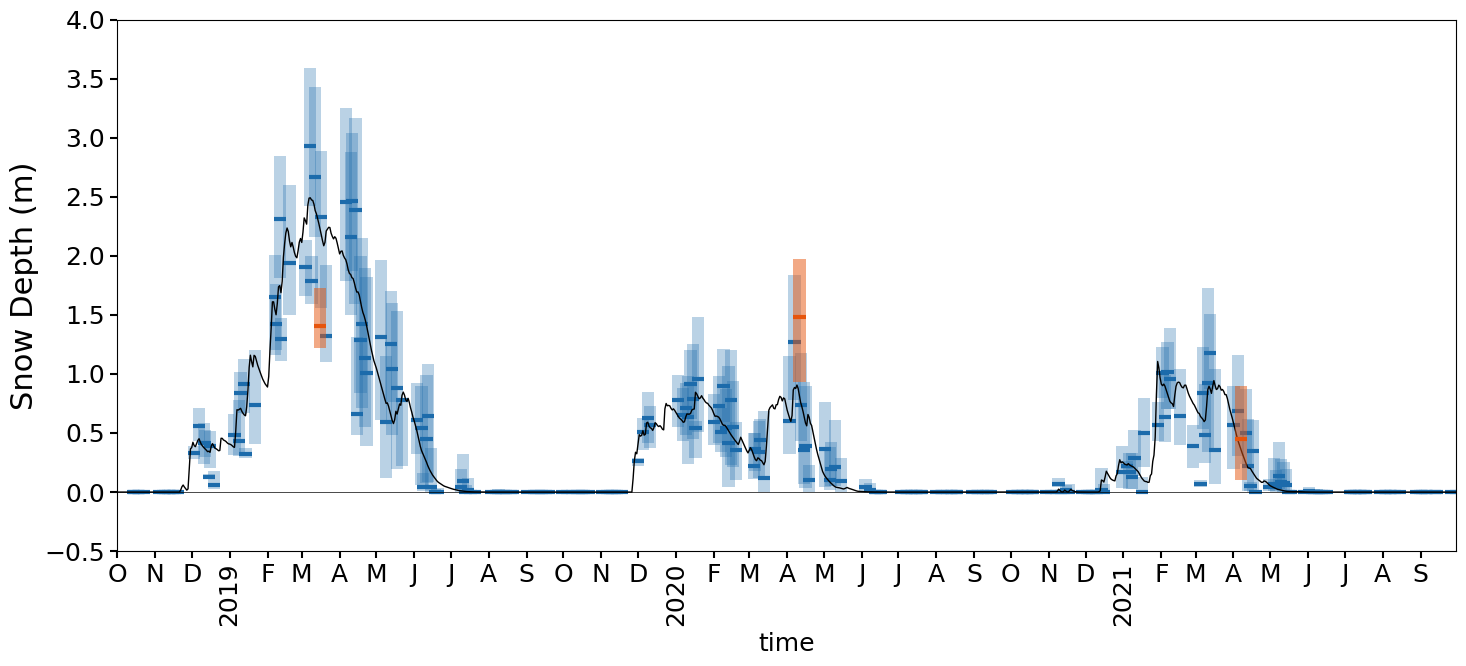

In [343]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='reanalysis_sd', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_reanalysis_highlights.png', 
                         main_color=reanalysis_color, highlight_color=highlight_color, clim=(-0.5, 4))

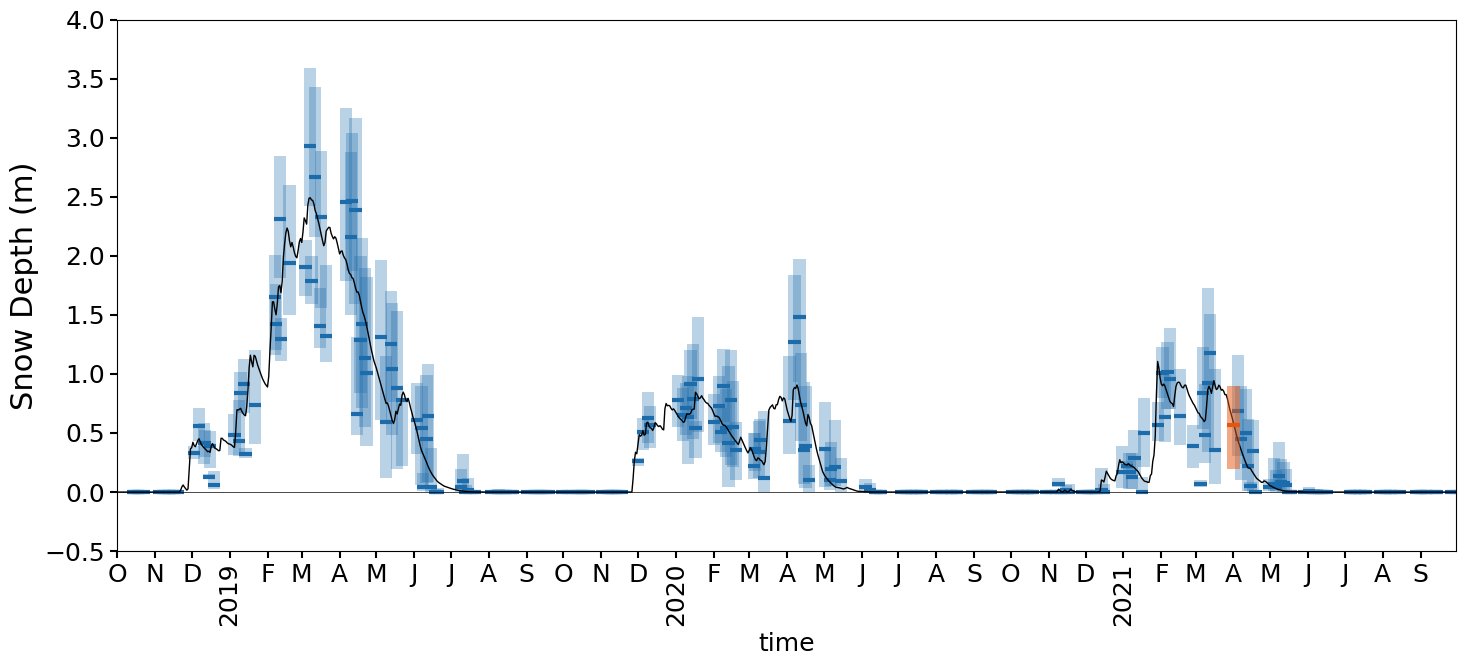

In [47]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='reanalysis_sd', groupby_col='acqdate', highlights=[alt_highlight_dates[1]],
                         title='', name='../../figures/boxplots_reanalysis_highlights.png', 
                         main_color=reanalysis_color, highlight_color=highlight_color, clim=(-0.5, 4))

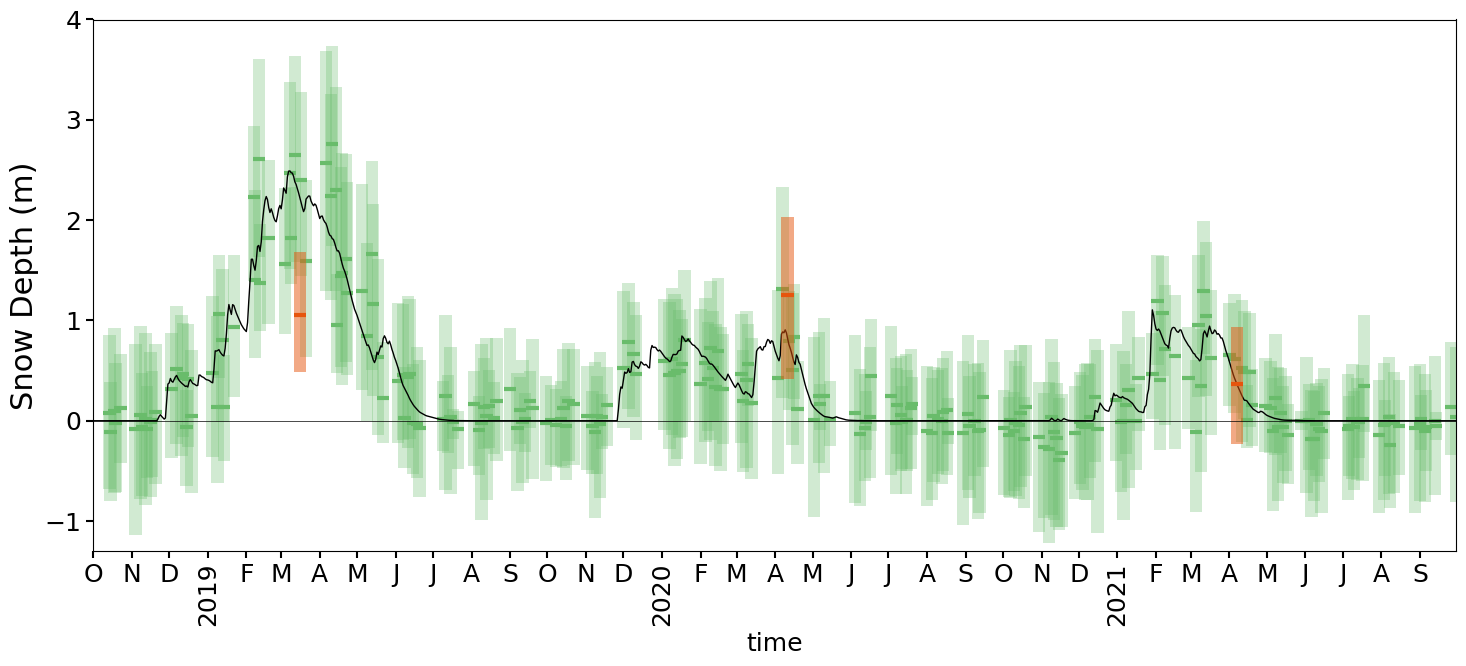

In [344]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, highlight_color=highlight_color, clim=(-1.3, 4))

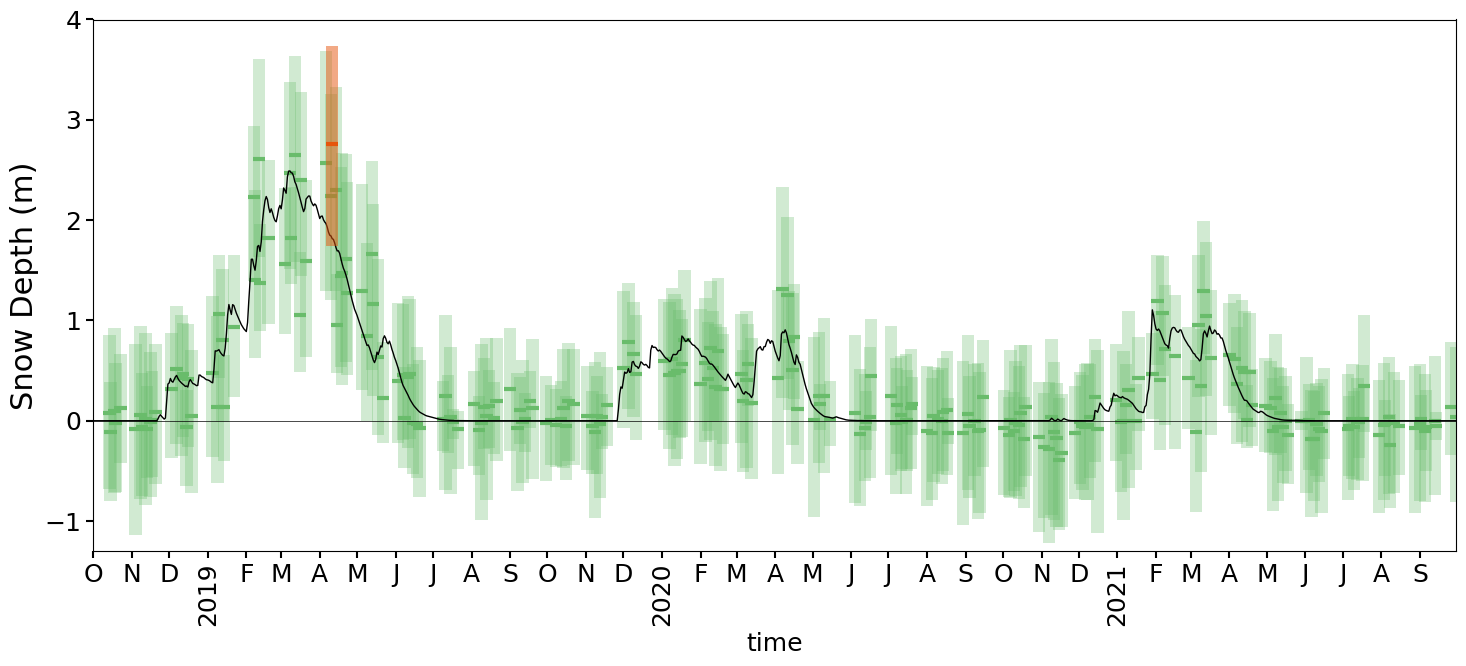

In [32]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, highlight_color=highlight_color, clim=(-1.3, 4))

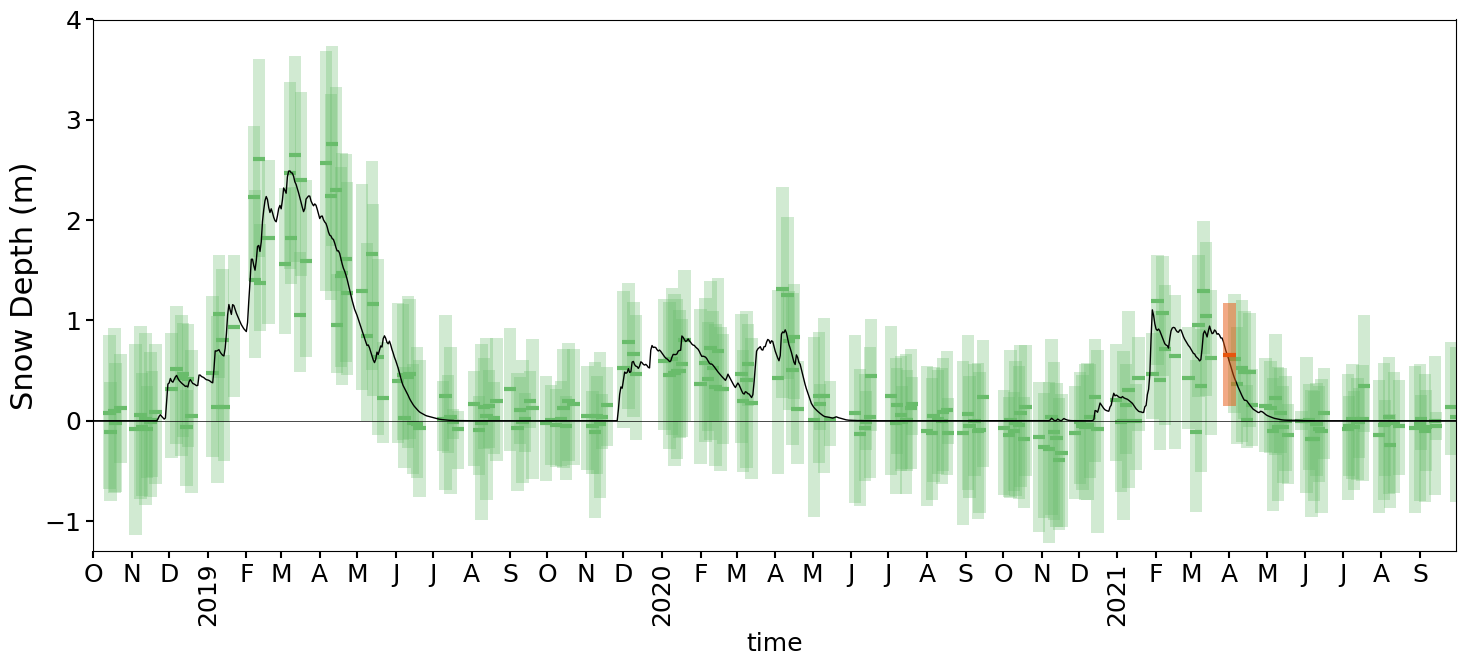

In [48]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_3dep_dif', groupby_col='acqdate', highlights=[alt_highlight_dates[1]],
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, highlight_color=highlight_color, clim=(-1.3, 4))

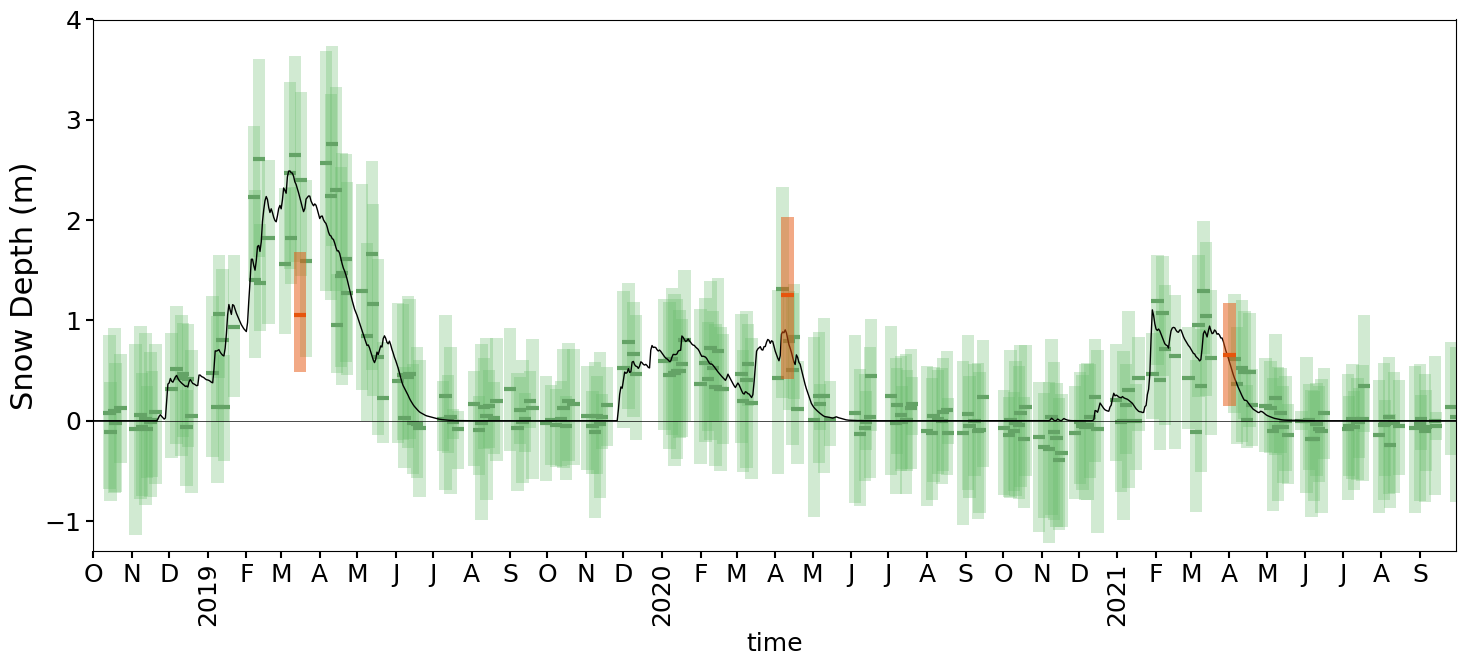

In [61]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100], col='icesat2_3dep_dif', groupby_col='acqdate', highlights=highlight_dates_dt,
                         title='', name='../../figures/boxplots_icesat2_highlights.png', 
                         main_color=icesat2_color, main_color_median=icesat2_median_color, highlight_color=highlight_color, clim=(-1.3, 4))

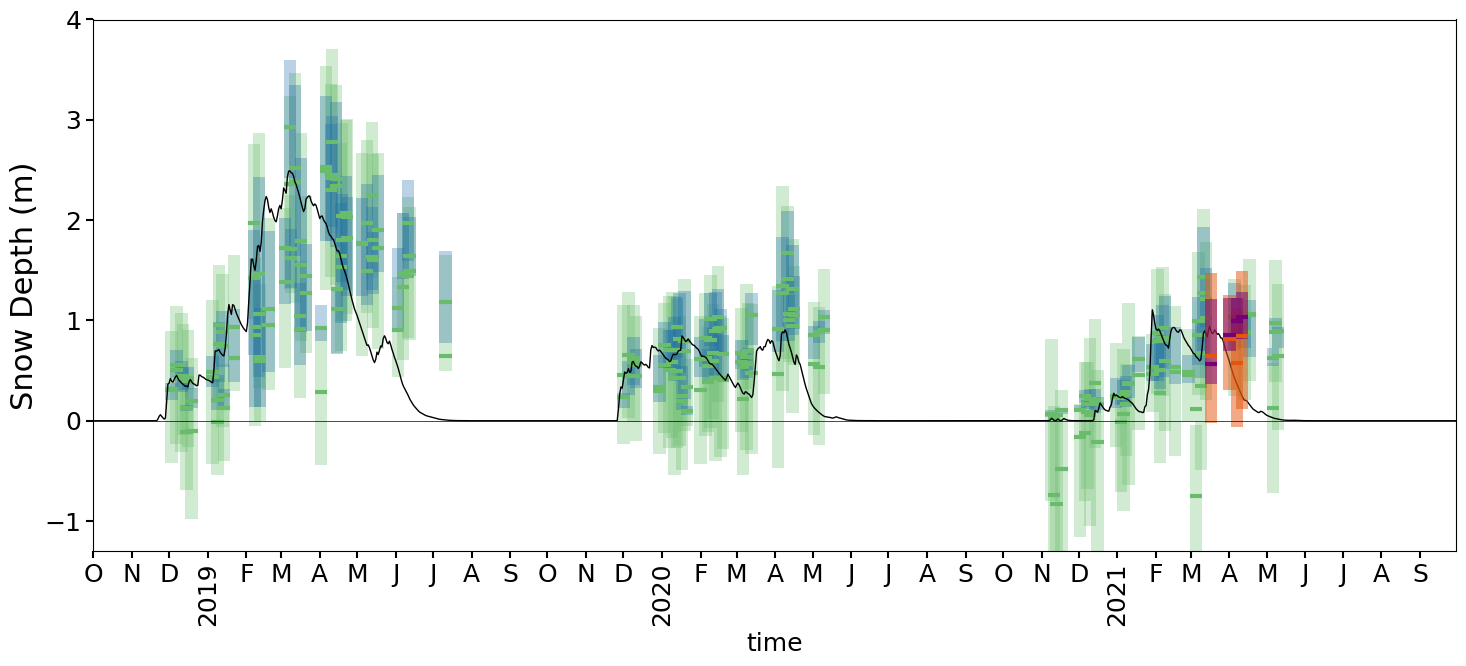

In [39]:
plt.rcParams['font.size'] = '18'
dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

boxplot_timeseries_highlights(df=atl06sr_gdf_fsca_9[(atl06sr_gdf_fsca_9['n']>100)], col='icesat2_3dep_dif', col2 = 'reanalysis_sd',
                              groupby_col='acqdate', highlights=alt_highlight_dates,
                         title='', name='../figures/boxplots_cdec_aso.jpeg', 
                         main_color=icesat2_color, main_color2 = reanalysis_color, highlight_color=highlight_color, 
                         highlight_color2 = highlight_color2, clim=(-1.3, 4))

#### Figure ideas:  
* ~~just plot the medians, not the boxplots~~  
* combine the subfigs into one figure with a good layout (including scatterplots of elevation with slope subsets)  
* test out adding some snotel lines to the timeseries plots - or add a shaded area giving a range of snotels?  
* ~~Determine the residuals for median reanalysis to median sampled reanalysis, and median reanalysis to median icesat2 for the timeseries.~~
* should i make a polygon out of the snowy mask? it's not the most spatially cohesive region so might be confusing. Need some way to show this region in the Fig. 2 insets  
* Identify and investigate the extreme negative cases, can I avoid plotting them for figure size concerns?  
* what to say about the positive / non-zero values in the summer? -> snow is more reflective. wildfire smoke?

In [72]:
# medians_both = atl06sr_gdf_snowy[atl06sr_gdf_snowy['n'] > 100][['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()
# residuals = pickle.load(open('../../data/results/sierras_sd_residuals.pkl', 'rb'))
# medians_both['snow_presence'] = residuals['snow_presence']


#Takes a long time to run

# medians_both['median_reanalysis'] = np.nan

# for date in medians_both.index:
#     medians_both.loc[(medians_both.index==date), 'median_reanalysis'] = median_sd.SD_Post.sel(time=pd.to_datetime(date))

#medians_both.to_pickle('../../data/results/medians_both_sierras.pkl')

In [56]:
medians_both = pickle.load(open('../../data/results/medians_both_sierras.pkl','rb'))

medians_both['acqdate_dt'] = pd.to_datetime(medians_both.index)

medians_both['acqdate_plotting'] = medians_both['acqdate_dt'].astype('str')

In [57]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,snow_presence,median_reanalysis,acqdate_dt,acqdate_plotting
acqdate,,,,,,,
2018-10-14,0.075891,0.0,2018-10-14,0,0.0,2018-10-14,2018-10-14
2018-10-15,-0.108008,0.0,2018-10-15,0,0.0,2018-10-15,2018-10-15
2018-10-18,0.093040,0.0,2018-10-18,0,0.0,2018-10-18,2018-10-18
2018-10-19,-0.018844,0.0,2018-10-19,0,0.0,2018-10-19,2018-10-19
2018-10-23,0.122762,0.0,2018-10-23,0,0.0,2018-10-23,2018-10-23
...,...,...,...,...,...,...,...
2021-09-06,-0.059516,0.0,2021-09-06,0,0.0,2021-09-06,2021-09-06
2021-09-13,-0.000564,0.0,2021-09-13,0,0.0,2021-09-13,2021-09-13
2021-09-14,-0.055093,0.0,2021-09-14,0,0.0,2021-09-14,2021-09-14


In [65]:
medians_both.loc[(medians_both['snow_presence']==1), 'acqdate_dt']

acqdate
2018-12-03   2018-12-03
2018-12-07   2018-12-07
2018-12-11   2018-12-11
2018-12-12   2018-12-12
2018-12-15   2018-12-15
                ...    
2021-05-29   2021-05-29
2021-06-02   2021-06-02
2021-06-04   2021-06-04
2021-06-06   2021-06-06
2021-06-10   2021-06-10
Name: acqdate_dt, Length: 149, dtype: datetime64[ns]

In [67]:
medians_both['date_difference'] = medians_both['acqdate_dt'].diff().dt.days

In [68]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,snow_presence,median_reanalysis,acqdate_dt,acqdate_plotting,date_difference
acqdate,,,,,,,,
2018-10-14,0.075891,0.0,2018-10-14,0,0.0,2018-10-14,2018-10-14,NaN
2018-10-15,-0.108008,0.0,2018-10-15,0,0.0,2018-10-15,2018-10-15,1.0
2018-10-18,0.093040,0.0,2018-10-18,0,0.0,2018-10-18,2018-10-18,3.0
2018-10-19,-0.018844,0.0,2018-10-19,0,0.0,2018-10-19,2018-10-19,1.0
2018-10-23,0.122762,0.0,2018-10-23,0,0.0,2018-10-23,2018-10-23,4.0
...,...,...,...,...,...,...,...,...
2021-09-06,-0.059516,0.0,2021-09-06,0,0.0,2021-09-06,2021-09-06,1.0
2021-09-13,-0.000564,0.0,2021-09-13,0,0.0,2021-09-13,2021-09-13,7.0
2021-09-14,-0.055093,0.0,2021-09-14,0,0.0,2021-09-14,2021-09-14,1.0


In [71]:
medians_both[['acqdate_dt', 'date_difference']].head(20)

,acqdate_dt,date_difference
acqdate,,
2018-10-14,2018-10-14,NaN
2018-10-15,2018-10-15,1.0
2018-10-18,2018-10-18,3.0
2018-10-19,2018-10-19,1.0
2018-10-23,2018-10-23,4.0
2018-11-04,2018-11-04,12.0
2018-11-08,2018-11-08,4.0
2018-11-09,2018-11-09,1.0
2018-11-12,2018-11-12,3.0


In [73]:
medians_both.loc[(medians_both['snow_presence']==1),'date_difference'].mean()

np.float64(4.429530201342282)

In [74]:
medians_both.loc[(medians_both['snow_presence']==1),'date_difference']

acqdate
2018-12-03    13.0
2018-12-07     4.0
2018-12-11     4.0
2018-12-12     1.0
2018-12-15     3.0
              ... 
2021-05-29    11.0
2021-06-02     4.0
2021-06-04     2.0
2021-06-06     2.0
2021-06-10     2.0
Name: date_difference, Length: 149, dtype: float64

### metrics for snow-on dates:

In [58]:
bias = np.mean(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] - 
                   medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'])

correlation = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'].dropna())[0,1]
rmse = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] -
                                    medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'])**2))

ubrmse = np.sqrt(rmse**2 - bias**2)

In [59]:
print('bias: ',bias)
print('correlation: ',correlation)
print('RMSE: ',rmse)
print('unbiased RMSE: ',ubrmse)

bias:  -0.017420121276202755
correlation:  0.960739961233009
RMSE:  0.1895140839111014
unbiased RMSE:  0.18871175738513582


### metrics for snow-off dates:

In [75]:
bias = np.mean(medians_both.loc[(medians_both['snow_presence']==0), 'icesat2_3dep_dif'] - 
                   medians_both.loc[(medians_both['snow_presence']==0), 'reanalysis_sd'])

correlation = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==0), 'icesat2_3dep_dif'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==0), 'reanalysis_sd'].dropna())[0,1]
rmse = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==0), 'icesat2_3dep_dif'] -
                                    medians_both.loc[(medians_both['snow_presence']==0), 'reanalysis_sd'])**2))

ubrmse = np.sqrt(rmse**2 - bias**2)

In [76]:
print('bias: ',bias)
print('correlation: ',correlation)
print('RMSE: ',rmse)
print('unbiased RMSE: ',ubrmse)

bias:  0.006930090153818956
correlation:  0.016188732024313025
RMSE:  0.10870052913529611
unbiased RMSE:  0.10847939382552477


In [82]:
# old highlight colors

# icesat2_color = '#69BC6B'
# reanalysis_color = '#1C6BAB'
# highlight_color = '#750075'

In [31]:
import altair as alt

In [11]:
source_nh = medians_both[(medians_both['snow_presence']==1) & (~medians_both['acqdate_dt'].isin(highlight_dates))]
source_h = medians_both[(medians_both['snow_presence']==1) & (medians_both['acqdate_dt'].isin(highlight_dates))]

max_val = max(medians_both['icesat2_3dep_dif'].max(), medians_both['reanalysis_sd'].max())
min_val = min(medians_both['icesat2_3dep_dif'].min(), medians_both['reanalysis_sd'].min())

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})


main_chart = alt.layer(alt.Chart(source_nh).mark_point(size=60, color='darkgrey', filled=True).encode(
    x=alt.X('icesat2_3dep_dif', title='ICESat-2 Median Snow Depth (m)'),
    y=alt.Y('reanalysis_sd', title= 'Sampled Reanalysis Median Snow Depth (m)')
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
    )


highlight_chart = alt.Chart(source_h).mark_point(size=70, color='darkgrey', filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif', title='ICESat-2 Median Snow Depth (m)'),
    y=alt.Y('reanalysis_sd', title= 'Sampled Reanalysis Median Snow Depth (m)'),
    shape=alt.Shape('acqdate_plotting:N')
)

# one_to_one_line = alt.Chart(line_data).mark_line(color='grey', strokeDash=[5, 5]).encode(
#     x='x:Q',
#     y='y:Q'
# )

# 5. Layer the charts
final_chart = main_chart  + highlight_chart

final_chart


NameError: name 'medians_both' is not defined

In [77]:
medians_both

,icesat2_3dep_dif,reanalysis_sd,date,snow_presence,median_reanalysis,acqdate_dt,acqdate_plotting,date_difference
acqdate,,,,,,,,
2018-10-14,0.075891,0.0,2018-10-14,0,0.0,2018-10-14,2018-10-14,NaN
2018-10-15,-0.108008,0.0,2018-10-15,0,0.0,2018-10-15,2018-10-15,1.0
2018-10-18,0.093040,0.0,2018-10-18,0,0.0,2018-10-18,2018-10-18,3.0
2018-10-19,-0.018844,0.0,2018-10-19,0,0.0,2018-10-19,2018-10-19,1.0
2018-10-23,0.122762,0.0,2018-10-23,0,0.0,2018-10-23,2018-10-23,4.0
...,...,...,...,...,...,...,...,...
2021-09-06,-0.059516,0.0,2021-09-06,0,0.0,2021-09-06,2021-09-06,1.0
2021-09-13,-0.000564,0.0,2021-09-13,0,0.0,2021-09-13,2021-09-13,7.0
2021-09-14,-0.055093,0.0,2021-09-14,0,0.0,2021-09-14,2021-09-14,1.0


In [78]:
medians_both['icesat2_medianreanalysis_dif'] = medians_both['icesat2_3dep_dif'] - medians_both['median_reanalysis']
medians_both['reanalysis_medianreanalysis_dif'] = medians_both['reanalysis_sd'] - medians_both['median_reanalysis']

In [158]:
# does not include unbiased rmse

bias_is2 = np.mean(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] - 
                   medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])
correlation_is2 = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'].dropna())[0,1]
rmse_is2 = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] -
                                    medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])**2))
#ubrmse_is2 = np.sqrt(rmse**2 - bias**2)

bias_r = np.mean(medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'] - 
                   medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])
correlation_r = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'].dropna())[0,1]
rmse_r = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'] -
                                    medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])**2))

bias_is2_r = np.mean(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] - 
                   medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'])
correlation_is2_r = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'].dropna())[0,1]
rmse_is2_r = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] -
                                    medians_both.loc[(medians_both['snow_presence']==1), 'reanalysis_sd'])**2))


metrics_data = pd.DataFrame({
    'metric': [bias_is2, bias_r, bias_is2_r, correlation_is2, correlation_r, correlation_is2_r, rmse_is2, rmse_is2, rmse_is2_r],
    'metric_label':['bias', 'bias','bias', 'correlation', 'correlation','correlation', 'rmse', 'rmse', 'rmse'],
    'labels': ['is2_reanalysismedian', 'r_reanalysismedian', 'is2_r', 'is2_reanalysismedian', 'r_reanalysismedian', 'is2_r','is2_reanalysismedian', 'r_reanalysismedian', 'is2_r'],
    'x_pos': [-0.4, 1.7, 1.5, -0.4, 1.7, 1.5, -0.4, 1.7, 1.5],
    'y_pos': [2.4, 0.4, 0.4, 2.25, 0.25, 0.25, 2.1, 0.1, 0.1]  #[-0.01,-0.01,-0.08, -0.08, -0.15, -0.15, -0.22, -0.22]
})

metrics_data['metric_2f'] = metrics_data['metric'].round(2)

In [122]:
plt.rcParams['axes.labelsize'] = '28'

In [177]:
source_nh = medians_both[(medians_both['snow_presence']==1) & (~medians_both['acqdate_dt'].isin(highlight_dates))]
source_h = medians_both[(medians_both['snow_presence']==1) & (medians_both['acqdate_dt'].isin(highlight_dates))]

max_val = max(medians_both['icesat2_3dep_dif'].max(), medians_both['reanalysis_sd'].max())
min_val = min(medians_both['icesat2_3dep_dif'].min(), medians_both['reanalysis_sd'].min())

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})


main_chart = alt.layer(alt.Chart(source_nh).mark_point(size=60, color='darkgrey', filled=True).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title='ICESat-2 Median Snow Depth (m)', titleFontSize=16)),
    y=alt.Y('reanalysis_sd', axis=alt.Axis(title='Sampled Reanalysis Median Snow Depth (m)', titleFontSize=16))
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
    )+ \
    alt.Chart(metrics_data[(metrics_data['labels']=='is2_r')]).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

highlight_chart = alt.Chart(source_h).mark_point(size=70, color='darkgrey', filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif'),
    y=alt.Y('reanalysis_sd'),
    shape=alt.Shape('acqdate_plotting:N')
    )


final_chart = (main_chart + highlight_chart)
final_chart.configure_axis(
    labelFontSize=14,
    titleFontSize=16
)

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_57964/2773505503.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh = medians_both[(medians_both['snow_presence']==1) & (~medians_both['acqdate_dt'].isin(highlight_dates))]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_57964/2773505503.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_h = medians_both[(medians_both['snow_presence']==1) & (medians_both['acqdate_dt'].isin(highlight_dates))]


alt.LayerChart(...)

In [32]:
# Same plot but using reanalysis_sca > 0.9 filter instead of mask==1
# Create new filtered dataset
atl06sr_gdf_sca = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca'] > 0.9) & (atl06sr_gdf['slope'] < 20)]
atl06sr_gdf_sca['n'] = atl06sr_gdf_sca.groupby('acqdate')['acqdate'].transform('count')

# Calculate medians per date and also get sample size per date
medians_sca = atl06sr_gdf_sca.loc[(atl06sr_gdf_sca['n'] > 100), 
                                   ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()
# Get sample size per date
sample_counts = atl06sr_gdf_sca.loc[(atl06sr_gdf_sca['n'] > 100), 
                                     ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').size()
medians_sca['sample_size'] = sample_counts
medians_sca['acqdate_dt'] = pd.to_datetime(medians_sca.index)
medians_sca['acqdate_plotting'] = medians_sca['acqdate_dt'].astype('str')

# Calculate metrics for SCA-filtered data (all dates, no snow_presence filter)
bias_sca = np.mean(medians_sca['icesat2_3dep_dif'] - medians_sca['reanalysis_sd'])
correlation_sca = np.corrcoef(medians_sca['icesat2_3dep_dif'].dropna(),
                              medians_sca['reanalysis_sd'].dropna())[0,1]
rmse_sca = np.sqrt(np.nanmean((medians_sca['icesat2_3dep_dif'] - medians_sca['reanalysis_sd'])**2))

print(f"Metrics using reanalysis_sca > 0.9 filter:")
print(f"  Bias: {bias_sca:.2f}")
print(f"  Correlation: {correlation_sca:.2f}")
print(f"  RMSE: {rmse_sca:.2f}")
print(f"  Number of dates: {len(medians_sca)}")

metrics_data_sca = pd.DataFrame({
    'metric': [bias_sca, correlation_sca, rmse_sca],
    'metric_label': ['bias', 'correlation', 'rmse'],
    'labels': ['is2_r'] * 3,
    'x_pos': [1.5, 1.5, 1.5],
    'y_pos': [0.4, 0.25, 0.1]
})
metrics_data_sca['metric_2f'] = metrics_data_sca['metric'].round(2)

# Create plot sources (no snow_presence filter - using all dates)
source_nh_sca = medians_sca[~medians_sca['acqdate_dt'].isin(highlight_dates)]
source_h_sca = medians_sca[medians_sca['acqdate_dt'].isin(highlight_dates)]

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})

main_chart_sca = alt.layer(alt.Chart(source_nh_sca).mark_point(size=60, filled=True).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title='ICESat-2 Median Snow Depth (m)', titleFontSize=16)),
    y=alt.Y('reanalysis_sd', axis=alt.Axis(title='Sampled Reanalysis Median Snow Depth (m)', titleFontSize=16)),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=alt.Legend(title='Sample Size'))
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
) + alt.Chart(metrics_data_sca).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    fontSize=15
).transform_calculate(
    annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
).encode(
    x=alt.X('x_pos:Q'),
    y=alt.Y('y_pos:Q'),
    text='annotation_text:N'
)

highlight_chart_sca = alt.Chart(source_h_sca).mark_point(size=70, filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif'),
    y=alt.Y('reanalysis_sd'),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=None),
    shape=alt.Shape('acqdate_plotting:N')
)

final_chart_sca = (main_chart_sca + highlight_chart_sca).properties(
    title='Using reanalysis_sca > 0.9 filter (instead of mask==1)'
)
final_chart_sca.configure_axis(
    labelFontSize=14,
    titleFontSize=16
)

Metrics using reanalysis_sca > 0.9 filter:
  Bias: -0.11
  Correlation: 0.93
  RMSE: 0.29
  Number of dates: 120


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/4018083285.py:38: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh_sca = medians_sca[~medians_sca['acqdate_dt'].isin(highlight_dates)]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/4018083285.py:39: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns]

alt.LayerChart(...)

In [ ]:
# snow_on_dates = median_sd.time.where(median_sd.SD_Post != 0).dropna('time')
# residuals['snow_presence'] = 0

# for day in snow_on_dates.values:
#     # Convert to Python datetime object
#     py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
#     py_date = py_datetime.date()

#     if py_date in residuals.index:
#         residuals.loc[py_date, 'snow_presence'] = 1
#     else:
#         continue

In [33]:
# Same plot but using mask==1 filter (with sample size coloring)
# Create new filtered dataset
atl06sr_gdf_mask = atl06sr_gdf[(atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['slope'] < 20)]
atl06sr_gdf_mask['n'] = atl06sr_gdf_mask.groupby('acqdate')['acqdate'].transform('count')

# Calculate medians per date and also get sample size per date
medians_mask = atl06sr_gdf_mask.loc[(atl06sr_gdf_mask['n'] > 100), 
                                   ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()
# Get sample size per date
sample_counts_mask = atl06sr_gdf_mask.loc[(atl06sr_gdf_mask['n'] > 100), 
                                     ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').size()
medians_mask['sample_size'] = sample_counts_mask
medians_mask['acqdate_dt'] = pd.to_datetime(medians_mask.index)
medians_mask['acqdate_plotting'] = medians_mask['acqdate_dt'].astype('str')

# Compute snow_presence based on dates where median SD != 0
import datetime
snow_on_dates = median_sd.time.where(median_sd.SD_Post != 0).dropna('time')
medians_mask['snow_presence'] = 0
for day in snow_on_dates.values:
    py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
    py_date = py_datetime.date()
    if py_date in medians_mask.index:
        medians_mask.loc[py_date, 'snow_presence'] = 1

# Calculate metrics for mask-filtered data (only snow_presence==1)
bias_mask = np.mean(medians_mask.loc[medians_mask['snow_presence']==1, 'icesat2_3dep_dif'] - 
                    medians_mask.loc[medians_mask['snow_presence']==1, 'reanalysis_sd'])
correlation_mask = np.corrcoef(medians_mask.loc[medians_mask['snow_presence']==1, 'icesat2_3dep_dif'].dropna(),
                              medians_mask.loc[medians_mask['snow_presence']==1, 'reanalysis_sd'].dropna())[0,1]
rmse_mask = np.sqrt(np.nanmean((medians_mask.loc[medians_mask['snow_presence']==1, 'icesat2_3dep_dif'] - 
                                medians_mask.loc[medians_mask['snow_presence']==1, 'reanalysis_sd'])**2))

n_dates_mask = (medians_mask['snow_presence']==1).sum()
print(f"Metrics using mask==1 filter:")
print(f"  Bias: {bias_mask:.2f}")
print(f"  Correlation: {correlation_mask:.2f}")
print(f"  RMSE: {rmse_mask:.2f}")
print(f"  Number of dates: {n_dates_mask}")

metrics_data_mask = pd.DataFrame({
    'metric': [bias_mask, correlation_mask, rmse_mask],
    'metric_label': ['bias', 'correlation', 'rmse'],
    'labels': ['is2_r'] * 3,
    'x_pos': [1.5, 1.5, 1.5],
    'y_pos': [0.4, 0.25, 0.1]
})
metrics_data_mask['metric_2f'] = metrics_data_mask['metric'].round(2)

# Create plot sources (only snow_presence==1)
source_nh_mask = medians_mask[(medians_mask['snow_presence']==1) & (~medians_mask['acqdate_dt'].isin(highlight_dates))]
source_h_mask = medians_mask[(medians_mask['snow_presence']==1) & (medians_mask['acqdate_dt'].isin(highlight_dates))]

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})

main_chart_mask = alt.layer(alt.Chart(source_nh_mask).mark_point(size=60, filled=True).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title='ICESat-2 Median Snow Depth (m)', titleFontSize=16)),
    y=alt.Y('reanalysis_sd', axis=alt.Axis(title='Sampled Reanalysis Median Snow Depth (m)', titleFontSize=16)),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=alt.Legend(title='Sample Size'))
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
) + alt.Chart(metrics_data_mask).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    fontSize=15
).transform_calculate(
    annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
).encode(
    x=alt.X('x_pos:Q'),
    y=alt.Y('y_pos:Q'),
    text='annotation_text:N'
)

highlight_chart_mask = alt.Chart(source_h_mask).mark_point(size=70, filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif'),
    y=alt.Y('reanalysis_sd'),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=None),
    shape=alt.Shape('acqdate_plotting:N')
)

final_chart_mask = (main_chart_mask + highlight_chart_mask).properties(
    title='Using mask==1 filter'
)
final_chart_mask.configure_axis(
    labelFontSize=14,

    titleFontSize=16)

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Metrics using mask==1 filter:
  Bias: -0.02
  Correlation: 0.96
  RMSE: 0.19
  Number of dates: 149


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/276248390.py:51: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh_mask = medians_mask[(medians_mask['snow_presence']==1) & (~medians_mask['acqdate_dt'].isin(highlight_dates))]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/276248390.py:52: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_h_mask = medians_mask[(medians_mask['snow_presence']==1) & (medians_mask['acqdate_dt'].isin(highlight_dates))]


alt.LayerChart(...)

In [53]:
median_sca_allyrs_roi

<xarray.DataArray 'SCA_Post' (time: 13514)> Size: 54kB
array([0.    , 0.    , 0.    , ..., 0.0026, 0.0002, 0.    ],
      shape=(13514,), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

In [56]:
# Same plot but using mask==1 filter (with sample size coloring)
# Create new filtered dataset
atl06sr_gdf_mask = atl06sr_gdf[(atl06sr_gdf['mask'] == 1) & (atl06sr_gdf['slope'] < 20)]
atl06sr_gdf_mask['n'] = atl06sr_gdf_mask.groupby('acqdate')['acqdate'].transform('count')

# Calculate medians per date and also get sample size per date
medians_mask = atl06sr_gdf_mask.loc[(atl06sr_gdf_mask['n'] > 100), 
                                   ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()
# Get sample size per date
sample_counts_mask = atl06sr_gdf_mask.loc[(atl06sr_gdf_mask['n'] > 100), 
                                     ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').size()
medians_mask['sample_size'] = sample_counts_mask
medians_mask['acqdate_dt'] = pd.to_datetime(medians_mask.index)
medians_mask['acqdate_plotting'] = medians_mask['acqdate_dt'].astype('str')

# Compute snow_presence_fsca based on dates where median fsca >0.1
import datetime
snow_on_dates = median_sca_allyrs_roi.sel(time=slice('2018-10-01', '2021-09-30')).time.where(median_sca_allyrs_roi.sel(time=slice('2018-10-01', '2021-09-30')) > 0.1).dropna('time')
medians_mask['snow_presence_fsca'] = 0
for day in snow_on_dates.values:
    py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
    py_date = py_datetime.date()
    if py_date in medians_mask.index:
        medians_mask.loc[py_date, 'snow_presence_fsca'] = 1

# Calculate metrics for mask-filtered data (only snow_presence_fsca==1)
bias_mask = np.mean(medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'icesat2_3dep_dif'] - 
                    medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'reanalysis_sd'])
correlation_mask = np.corrcoef(medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'icesat2_3dep_dif'].dropna(),
                              medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'reanalysis_sd'].dropna())[0,1]
rmse_mask = np.sqrt(np.nanmean((medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'icesat2_3dep_dif'] - 
                                medians_mask.loc[medians_mask['snow_presence_fsca']==1, 'reanalysis_sd'])**2))

n_dates_mask = (medians_mask['snow_presence_fsca']==1).sum()
print(f"Metrics using mask==1 filter:")
print(f"  Bias: {bias_mask:.2f}")
print(f"  Correlation: {correlation_mask:.2f}")
print(f"  RMSE: {rmse_mask:.2f}")
print(f"  Number of dates: {n_dates_mask}")

metrics_data_mask = pd.DataFrame({
    'metric': [bias_mask, correlation_mask, rmse_mask],
    'metric_label': ['bias', 'correlation', 'rmse'],
    'labels': ['is2_r'] * 3,
    'x_pos': [1.5, 1.5, 1.5],
    'y_pos': [0.4, 0.25, 0.1]
})
metrics_data_mask['metric_2f'] = metrics_data_mask['metric'].round(2)

# Create plot sources (only snow_presence_fsca==1)
source_nh_mask = medians_mask[(medians_mask['snow_presence_fsca']==1) & (~medians_mask['acqdate_dt'].isin(highlight_dates))]
source_h_mask = medians_mask[(medians_mask['snow_presence_fsca']==1) & (medians_mask['acqdate_dt'].isin(highlight_dates))]

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})

main_chart_mask = alt.layer(alt.Chart(source_nh_mask).mark_point(size=60, filled=True).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title='ICESat-2 Median Snow Depth (m)', titleFontSize=16)),
    y=alt.Y('reanalysis_sd', axis=alt.Axis(title='Sampled Reanalysis Median Snow Depth (m)', titleFontSize=16)),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=alt.Legend(title='Sample Size'))
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
) + alt.Chart(metrics_data_mask).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    fontSize=15
).transform_calculate(
    annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
).encode(
    x=alt.X('x_pos:Q'),
    y=alt.Y('y_pos:Q'),
    text='annotation_text:N'
)

highlight_chart_mask = alt.Chart(source_h_mask).mark_point(size=70, filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif'),
    y=alt.Y('reanalysis_sd'),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=None),
    shape=alt.Shape('acqdate_plotting:N')
)

final_chart_mask = (main_chart_mask + highlight_chart_mask).properties(
    title='Using mask==1 filter'
)
final_chart_mask.configure_axis(
    labelFontSize=14,

    titleFontSize=16)

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Metrics using mask==1 filter:
  Bias: -0.01
  Correlation: 0.96
  RMSE: 0.20
  Number of dates: 121


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/64782104.py:51: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh_mask = medians_mask[(medians_mask['snow_presence_fsca']==1) & (~medians_mask['acqdate_dt'].isin(highlight_dates))]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/64782104.py:52: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_h_mask = medians_mask[(medians_mask['snow_presence_fsca']==1) & (medians_mask['acqdate_dt'].isin(highlight_dates))]


alt.LayerChart(...)

In [34]:
# Same plot but using reanalysis_sca > 0.9 filter instead of mask==1
# Create new filtered dataset
atl06sr_gdf_sca = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca'] > 0.9) & (atl06sr_gdf['slope'] < 20)]
atl06sr_gdf_sca['n'] = atl06sr_gdf_sca.groupby('acqdate')['acqdate'].transform('count')

# Calculate medians per date and also get sample size per date
medians_sca = atl06sr_gdf_sca.loc[(atl06sr_gdf_sca['n'] > 100), 
                                   ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()
# Get sample size per date
sample_counts = atl06sr_gdf_sca.loc[(atl06sr_gdf_sca['n'] > 100), 
                                     ['icesat2_3dep_dif', 'reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').size()
medians_sca['sample_size'] = sample_counts
medians_sca['acqdate_dt'] = pd.to_datetime(medians_sca.index)
medians_sca['acqdate_plotting'] = medians_sca['acqdate_dt'].astype('str')

# Compute snow_presence based on dates where median SD != 0
import datetime
snow_on_dates = median_sd.time.where(median_sd.SD_Post != 0).dropna('time')
medians_sca['snow_presence'] = 0
for day in snow_on_dates.values:
    py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
    py_date = py_datetime.date()
    if py_date in medians_sca.index:
        medians_sca.loc[py_date, 'snow_presence'] = 1

# Calculate metrics for SCA-filtered data (only snow_presence==1)
bias_sca = np.mean(medians_sca.loc[medians_sca['snow_presence']==1, 'icesat2_3dep_dif'] - 
                   medians_sca.loc[medians_sca['snow_presence']==1, 'reanalysis_sd'])
correlation_sca = np.corrcoef(medians_sca.loc[medians_sca['snow_presence']==1, 'icesat2_3dep_dif'].dropna(),
                              medians_sca.loc[medians_sca['snow_presence']==1, 'reanalysis_sd'].dropna())[0,1]
rmse_sca = np.sqrt(np.nanmean((medians_sca.loc[medians_sca['snow_presence']==1, 'icesat2_3dep_dif'] - 
                               medians_sca.loc[medians_sca['snow_presence']==1, 'reanalysis_sd'])**2))

n_dates_sca = (medians_sca['snow_presence']==1).sum()
print(f"Metrics using reanalysis_sca > 0.9 filter:")
print(f"  Bias: {bias_sca:.2f}")
print(f"  Correlation: {correlation_sca:.2f}")
print(f"  RMSE: {rmse_sca:.2f}")
print(f"  Number of dates: {n_dates_sca}")

metrics_data_sca = pd.DataFrame({
    'metric': [bias_sca, correlation_sca, rmse_sca],
    'metric_label': ['bias', 'correlation', 'rmse'],
    'labels': ['is2_r'] * 3,
    'x_pos': [1.5, 1.5, 1.5],
    'y_pos': [0.4, 0.25, 0.1]
})
metrics_data_sca['metric_2f'] = metrics_data_sca['metric'].round(2)

# Create plot sources (only snow_presence==1)
source_nh_sca = medians_sca[(medians_sca['snow_presence']==1) & (~medians_sca['acqdate_dt'].isin(highlight_dates))]
source_h_sca = medians_sca[(medians_sca['snow_presence']==1) & (medians_sca['acqdate_dt'].isin(highlight_dates))]

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})

main_chart_sca = alt.layer(alt.Chart(source_nh_sca).mark_point(size=60, filled=True).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title='ICESat-2 Median Snow Depth (m)', titleFontSize=16)),
    y=alt.Y('reanalysis_sd', axis=alt.Axis(title='Sampled Reanalysis Median Snow Depth (m)', titleFontSize=16)),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=alt.Legend(title='Sample Size'))
),
    alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
) + alt.Chart(metrics_data_sca).mark_text(
    align='left',
    baseline='middle',
    dx=5,
    fontSize=15
).transform_calculate(
    annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
).encode(
    x=alt.X('x_pos:Q'),
    y=alt.Y('y_pos:Q'),
    text='annotation_text:N'
)

highlight_chart_sca = alt.Chart(source_h_sca).mark_point(size=70, filled=True, stroke=highlight_color, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif'),
    y=alt.Y('reanalysis_sd'),
    color=alt.Color('sample_size:Q', scale=alt.Scale(scheme='viridis', type='log'), legend=None),
    shape=alt.Shape('acqdate_plotting:N')
)

final_chart_sca = (main_chart_sca + highlight_chart_sca).properties(
    title='Using reanalysis_sca > 0.9 filter (instead of mask==1)'
)
final_chart_sca.configure_axis(
    labelFontSize=14,

    titleFontSize=16)

Metrics using reanalysis_sca > 0.9 filter:
  Bias: -0.11
  Correlation: 0.93
  RMSE: 0.29
  Number of dates: 116


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/168287621.py:51: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh_sca = medians_sca[(medians_sca['snow_presence']==1) & (~medians_sca['acqdate_dt'].isin(highlight_dates))]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_6445/168287621.py:52: FutureWarning: The behavior

alt.LayerChart(...)

In [ ]:
# by only filtering on sca >0.9, i allow back in lower elevation points

In [178]:
final_chart.save('../../figures/scatter_is2_sampled_reanalysis_highlights.png', dpi=500)

In [166]:
source_nh = medians_both[(medians_both['snow_presence']==1) & (~medians_both['acqdate_dt'].isin(highlight_dates))]
source_h = medians_both[(medians_both['snow_presence']==1) & (medians_both['acqdate_dt'].isin(highlight_dates))]

max_val = max(medians_both['icesat2_3dep_dif'].max(), medians_both['median_reanalysis'].max())
min_val = min(medians_both['icesat2_3dep_dif'].min(), medians_both['median_reanalysis'].min())

# Create a small DataFrame for the 1:1 line
line_data = pd.DataFrame({
    'x': [0, 3],
    'y': [0, 3]
})


icesat2_chart = alt.layer(alt.Chart(source_nh).mark_circle(size=60, color=icesat2_color, opacity=0.6).encode(
    x=alt.X('icesat2_3dep_dif', axis=alt.Axis(title=['ICESat-2 and Sampled Reanalysis', 'Median Snow Depth (m)'] , titleFontSize=16), scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis', scale=alt.Scale(domain=[0, 3]))
),
alt.Chart(line_data).mark_line(color='black', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)

icesat2_emphasis = alt.Chart(source_nh).mark_circle(size=5, color=icesat2_color).encode(
    x=alt.X('icesat2_3dep_dif', scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis', scale=alt.Scale(domain=[0, 3]))
)

reanalysis_chart = alt.Chart(source_nh).mark_circle(size=60, color=reanalysis_color, opacity=0.6).encode(
    x=alt.X('reanalysis_sd', scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis', axis=alt.Axis(title='Reanalysis Median Snow Depth (m)', titleFontSize=16), scale=alt.Scale(domain=[0, 3]))
)

reanalysis_emphasis = alt.Chart(source_nh).mark_circle(size=5, color=reanalysis_color).encode(
    x=alt.X('reanalysis_sd', scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis', scale=alt.Scale(domain=[0, 3]))
)

icesat2_highlights = alt.layer(alt.layer(alt.Chart(source_h).mark_point(size=80, color=icesat2_color, stroke=highlight_color, filled=True, fillOpacity=0.5, strokeOpacity=1, strokeWidth=3).encode(
    x=alt.X('icesat2_3dep_dif', scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis',  scale=alt.Scale(domain=[0, 3])),
    shape=alt.Shape('acqdate_plotting:N')
)) + \
    alt.Chart(metrics_data[(metrics_data['labels']=='is2_reanalysismedian')]).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

)

reanalysis_highlights = alt.layer(alt.Chart(source_h).mark_point(size=80, color=reanalysis_color, stroke=highlight_color, filled=True, fillOpacity=0.5, strokeOpacity=1, strokeWidth=3).encode(
    x=alt.X('reanalysis_sd', scale=alt.Scale(domain=[-0.5, 3])),
    y=alt.Y('median_reanalysis', scale=alt.Scale(domain=[0, 3])),
    shape=alt.Shape('acqdate_plotting:N')
)+ \
    alt.Chart(metrics_data[(metrics_data['labels']=='r_reanalysismedian')]).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )
)

# 5. Layer the charts
final_chart2 = (icesat2_chart + reanalysis_chart + icesat2_highlights + reanalysis_highlights) #+ icesat2_emphasis + reanalysis_emphasis

final_chart2.configure_axis(
    labelFontSize=14
    
)

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_57964/3365506806.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_nh = medians_both[(medians_both['snow_presence']==1) & (~medians_both['acqdate_dt'].isin(highlight_dates))]
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_57964/3365506806.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  source_h = medians_both[(medians_both['snow_presence']==1) & (medians_both['acqdate_dt'].isin(highlight_dates))]


alt.LayerChart(...)

In [167]:
final_chart2.save('../../figures/scatter_is2_sampled_reanalysis_median_reanalysis_highlights.png', dpi=500)

In [60]:
bias = np.mean(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] - 
                   medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])

correlation = np.corrcoef(medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'].dropna(),
                        medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'].dropna())[0,1]

rmse = np.sqrt(np.nanmean((medians_both.loc[(medians_both['snow_presence']==1), 'icesat2_3dep_dif'] -
                                    medians_both.loc[(medians_both['snow_presence']==1), 'median_reanalysis'])**2))

ubrmse = np.sqrt(rmse**2 - bias**2)

In [61]:
print('bias: ',bias)
print('correlation: ',correlation)
print('RMSE: ',rmse)
print('unbiased RMSE: ',ubrmse)

bias:  -0.018418777442902195
correlation:  0.8851936914855429
RMSE:  0.3166972871975717
unbiased RMSE:  0.3161612252566877


### Plot the spatial distribution of the selected dates:

In [32]:
highlight_dates_dt = pd.to_datetime(highlight_dates)

In [28]:
weird_dates = pd.to_datetime(weird_dates)

In [26]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [27]:
swe_sca_ds = swe_sca_ds.rename({'lat': 'y', 'lon': 'x'})
swe_sca_ds_roi = swe_sca_ds_roi.rename({'lat': 'y', 'lon': 'x'})

In [41]:
swe_sca_ds_roi

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [29]:
plt.rcParams['font.size'] = '18'

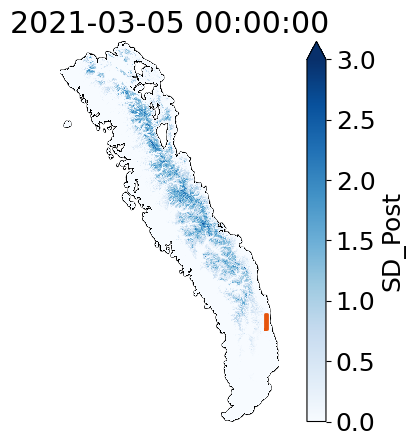

In [32]:
highlight_index = 1

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=weird_dates[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title(f'{weird_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orane_{highlight_index}.png',dpi=300)

In [33]:
atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index]), 'n']

time_ns
2021-03-05 05:40:37.377694208    487
2021-03-05 05:40:37.380510720    487
2021-03-05 05:40:37.383321088    487
2021-03-05 05:40:37.386129408    487
2021-03-05 05:40:37.388936192    487
                                ... 
2021-03-05 05:40:41.139778304    487
2021-03-05 05:40:41.145394688    487
2021-03-05 05:40:41.151016960    487
2021-03-05 05:40:41.162289408    487
2021-03-05 05:40:41.238413568    487
Name: n, Length: 487, dtype: int64

<Axes: >

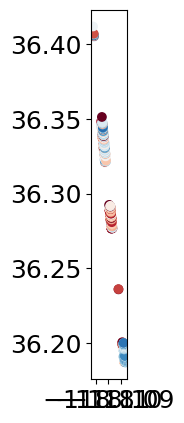

In [36]:
atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==weird_dates[highlight_index])].plot(column='icesat2_3dep_dif', cmap='RdBu',vmin=-3, vmax=3)

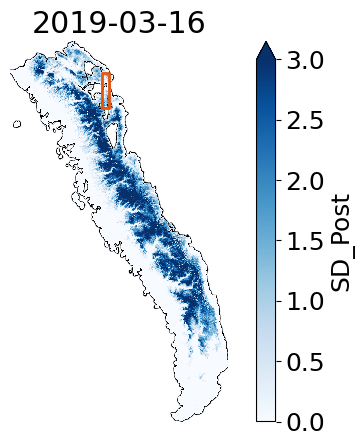

In [205]:
highlight_index = 0

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
fig.savefig(f'../../figures/sierra_map_highlight_orane_{highlight_index}.png',dpi=300)

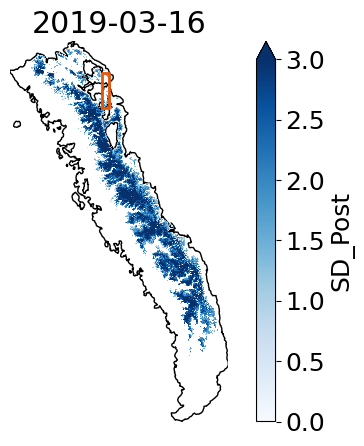

In [46]:
highlight_index = 0

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds_roi.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orane_{highlight_index}.png',dpi=300)

In [132]:
atl06sr_gdf_snowy

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,acqdate,reanalysis_swe,reanalysis_sca,reanalysis_sd,icesat2_3dep_dif,dif_plus,offset_sd,mask,acqdate_dt,n
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:33.097217024,0.0,1.0,0,2139.365493,6,30.952135,30,24,14.159952,158913789952,...,2018-10-14,0.0,0.0,0.0,4.165757,4.220486,4.220486,1,2018-10-14,20342
2018-10-14 11:40:33.100024576,0.0,1.0,0,2151.848519,6,33.023067,30,22,16.783373,158913789952,...,2018-10-14,0.0,0.0,0.0,3.708366,3.763094,3.763094,1,2018-10-14,20342
2018-10-14 11:40:33.102834176,0.0,1.0,0,2165.369876,6,33.457503,30,11,14.611403,158913789952,...,2018-10-14,0.0,0.0,0.0,2.220212,2.274940,2.274940,1,2018-10-14,20342
2018-10-14 11:40:33.122541824,0.0,1.0,0,2240.212942,6,31.350461,30,11,14.774078,158913789952,...,2018-10-14,0.0,0.0,0.0,0.844187,0.898915,0.898915,1,2018-10-14,20342
2018-10-14 11:40:33.125364992,0.0,1.0,0,2251.848530,6,31.454143,30,13,14.970673,158913789952,...,2018-10-14,0.0,0.0,0.0,0.820904,0.875633,0.875633,1,2018-10-14,20342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:55:53.836192256,0.0,1.0,0,2180.425529,6,12.267178,20,10,3.594358,94489280512,...,2021-09-30,0.0,0.0,0.0,-0.045646,0.009083,0.009083,1,2021-09-30,13944
2021-09-30 07:55:53.847510784,0.0,1.0,0,2178.047853,6,7.683628,20,10,4.090356,94489280512,...,2021-09-30,0.0,0.0,0.0,1.346190,1.400919,1.400919,1,2021-09-30,13944
2021-09-30 07:55:53.850336000,0.0,1.0,0,2176.360540,6,7.536188,20,10,3.000000,94489280512,...,2021-09-30,0.0,0.0,0.0,0.731745,0.786474,0.786474,1,2021-09-30,13944


<Axes: >

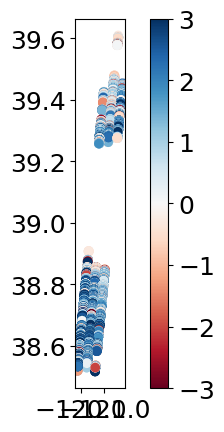

In [93]:
highlight_index = 1

fig, ax = plt.subplots()

atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].plot(ax=ax, column='icesat2_3dep_dif', cmap='RdBu', vmin=-3, vmax=3, legend=True)

<Axes: >

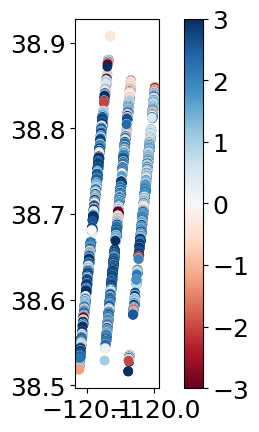

In [94]:
highlight_index = 1

fig, ax = plt.subplots()

atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y<39)].plot(ax=ax, column='icesat2_3dep_dif', cmap='RdBu', vmin=-3, vmax=3, legend=True)

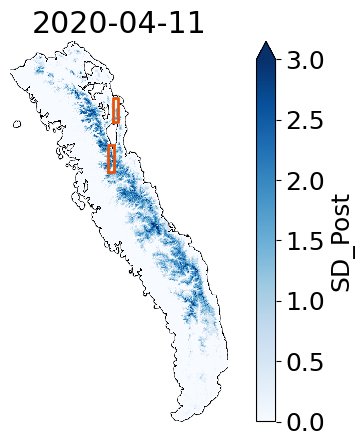

In [95]:
# test whether i should use two different boxes for this date

highlight_index = 1

min_x1 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y<39)].geometry.x.min()
min_y1 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y<39)].geometry.y.min()
max_x1 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y<39)].geometry.x.max()
max_y1 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y<39)].geometry.y.max()

min_x2 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y>39)].geometry.x.min()
min_y2 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y>39)].geometry.y.min()
max_x2 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y>39)].geometry.x.max()
max_y2 = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100) & (atl06sr_gdf_snowy.geometry.y>39)].geometry.y.max()

region1 = [  {"lon": min_x1, "lat": min_y1},
            {"lon": max_x1, "lat": min_y1},
            {"lon": max_x1, "lat": max_y1},
            {"lon": min_x1, "lat": max_y1},
            {"lon": min_x1, "lat": min_y1}  ]

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon1 = [e["lon"] for e in region1]
region_lat1 = [e["lat"] for e in region1]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]

fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon1, region_lat1, linewidth=2, color=highlight_color)
ax.plot(region_lon2, region_lat2, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

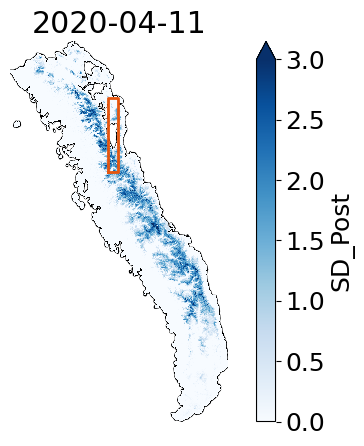

In [206]:
highlight_index = 1

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

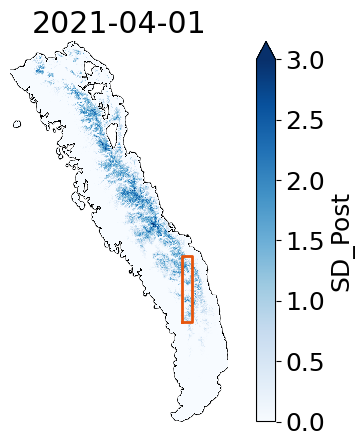

In [89]:
highlight_index = 2

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

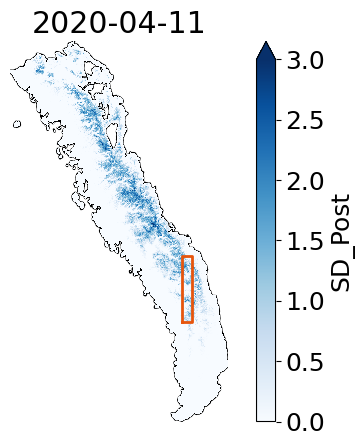

In [340]:
highlight_index = 1

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=alt_highlight_dates[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
ax.plot(region_lon, region_lat, linewidth=2, color=highlight_color)
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

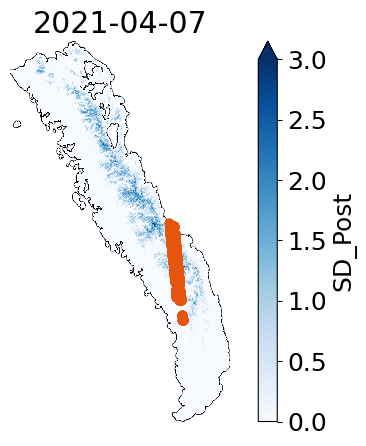

In [252]:
highlight_index = 2

fig, ax = plt.subplots()

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates_dt[2]].plot(ax=ax, color=highlight_color)
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

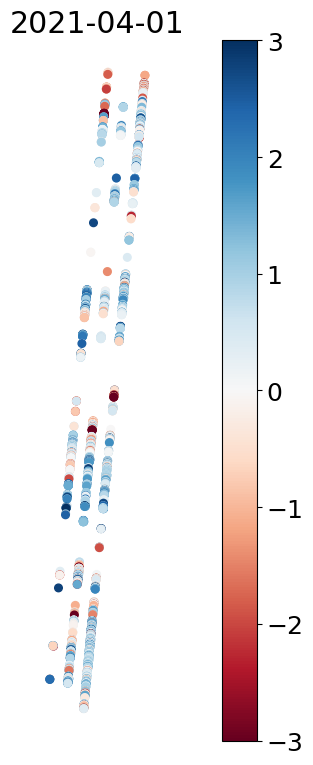

In [47]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(15,8))

#sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[2]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

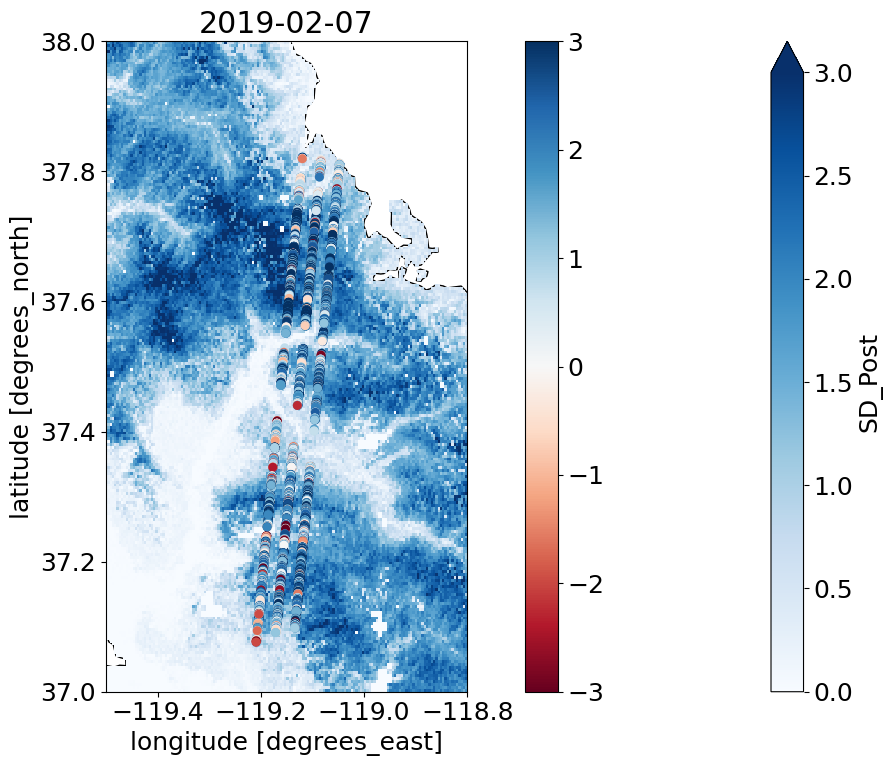

In [59]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(15,8))

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=pd.to_datetime('2019-02-07')).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==pd.to_datetime('2019-02-07')].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#ax.set_axis_off()
ax.set_title('')
ax.set_title('2019-02-07')
ax.set_xlim(-119.5,-118.8)
ax.set_ylim(37,38)

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

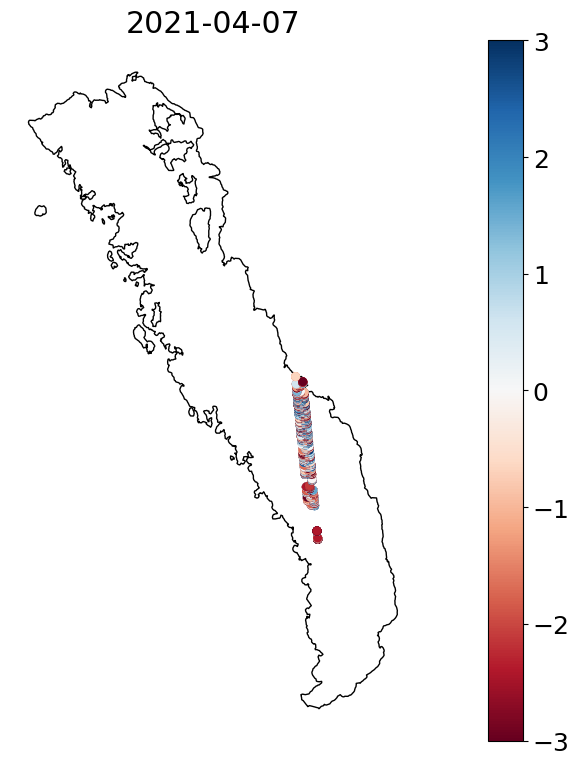

In [315]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(15,8))

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates_dt[2]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

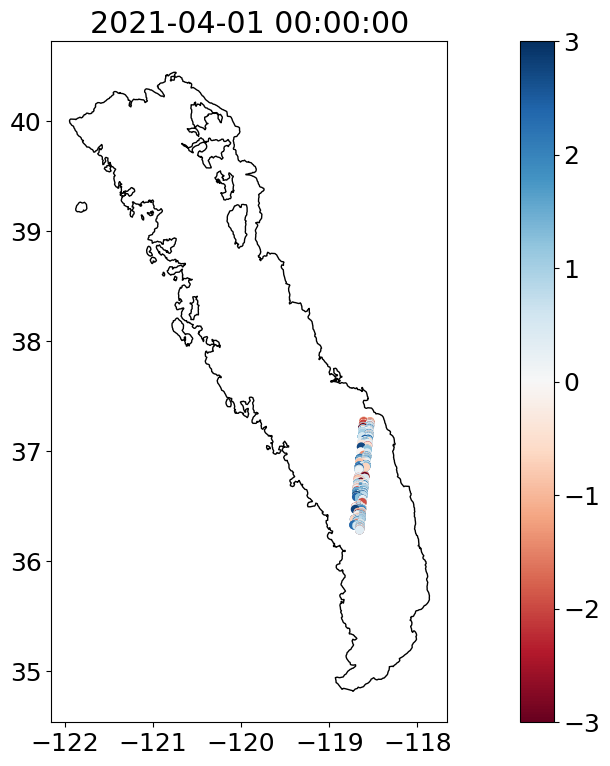

In [362]:
highlight_index = 1

fig, ax = plt.subplots(figsize=(15,8))

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{alt_highlight_dates[highlight_index]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

In [292]:
sierras_dem = xr.open_dataset('../../data/3dep/dem_200m_sierras.nc')

In [296]:
subset_bbox = (-118.95, 37.3, -118.85, 37.4)

In [298]:
import py3dep

In [302]:
dem_10 = py3dep.get_map("DEM", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

In [294]:
sierras_dem

<xarray.Dataset> Size: 32MB
Dimensions:      (x: 2397, y: 3302)
Coordinates:
  * x            (x) float64 19kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
  * y            (y) float64 26kB 40.45 40.44 40.44 40.44 ... 34.82 34.82 34.82
Data variables:
    spatial_ref  int64 8B ...
    elevation    (y, x) float32 32MB ...

In [356]:
highlight_dates_dt[highlight_index]

Timestamp('2021-04-07 00:00:00')

In [357]:

highlight_dates

['2019-03-16', '2020-04-11', '2021-04-01']

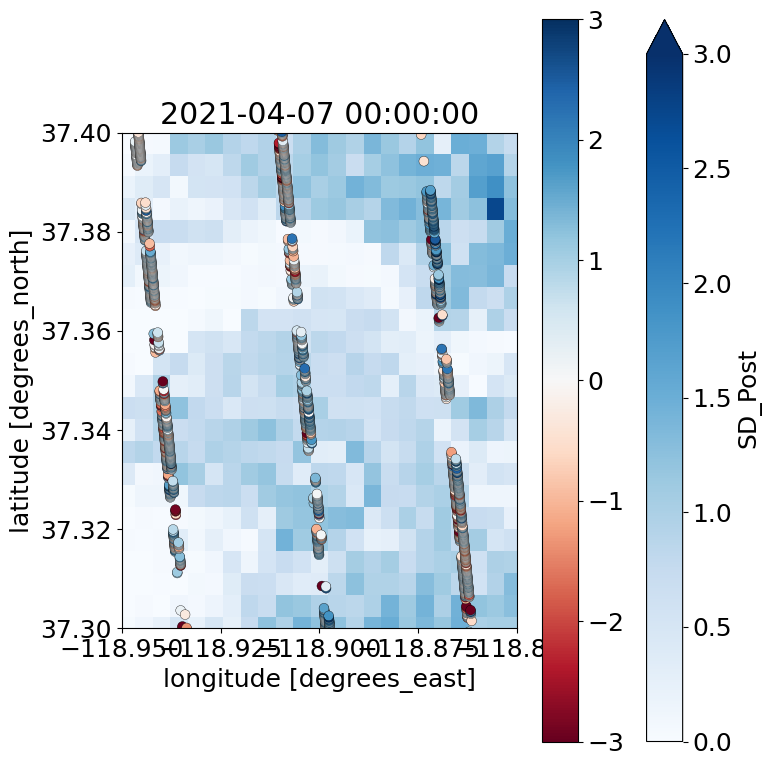

In [376]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(8,8))

#sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
#dem_10.plot(ax=ax, cmap='Greys')
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates_dt[highlight_index]].plot(ax=ax, column='icesat2_3dep_dif',markersize=50, cmap='RdBu', 
                                                                                edgecolor='k', linewidth=0.25, legend=True, vmin=-3, vmax=3) #
#ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates_dt[highlight_index]}')
ax.set_xlim(-118.95, -118.85)
ax.set_ylim(37.3, 37.4)

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

with this plot, do a zoom in of one beam pair. also annotate this figure to show areas with steep slope, places where there weren't enough photon returns to make an atl06 point, dense canopy cover, clouds, etc. Use it to save words in explaining ICESat-2 and of course reference other papers that explain icesat2
plot effects of n: use a single date, randomly subsample 10 different points x100 times (from a date with lots of data), for different sample sizes. use this to determine the sample size cutoff. doesn't need to be in the main paper, but need to have somehting to determine why we chose n.

In [355]:
highlight_dates_dt

DatetimeIndex(['2019-03-16', '2020-04-11', '2021-04-07'], dtype='datetime64[ns]', freq=None)

In [351]:
alt_highlight_dates

DatetimeIndex(['2021-03-17', '2021-04-01', '2021-04-07', '2021-04-11'], dtype='datetime64[ns]', freq=None)

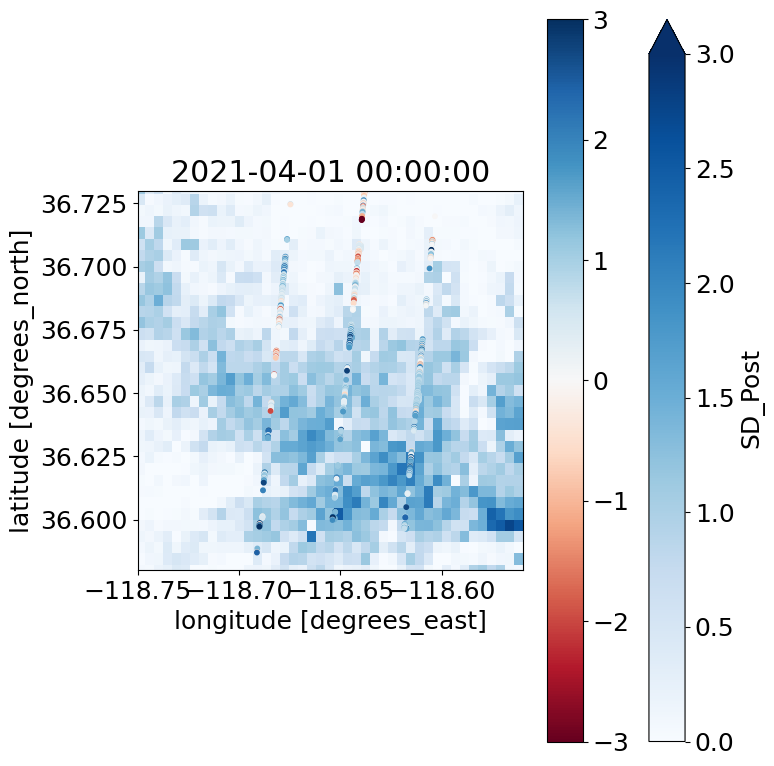

In [377]:
highlight_index = 1

fig, ax = plt.subplots(figsize=(8,8))

#sierras.plot(ax=ax, facecolor='none', edgecolor='k')
swe_sca_ds.SD_Post.sel(time=alt_highlight_dates[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
#dem_10.plot(ax=ax, cmap='Greys')
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]].plot(ax=ax, column='icesat2_3dep_dif',markersize=10, cmap='RdBu', 
                                                                                legend=True, vmin=-3, vmax=3) #edgecolor='k', linewidth=0.25, 
#ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{alt_highlight_dates[highlight_index]}')
ax.set_xlim(-118.75, -118.56)
ax.set_ylim(36.58, 36.73)

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

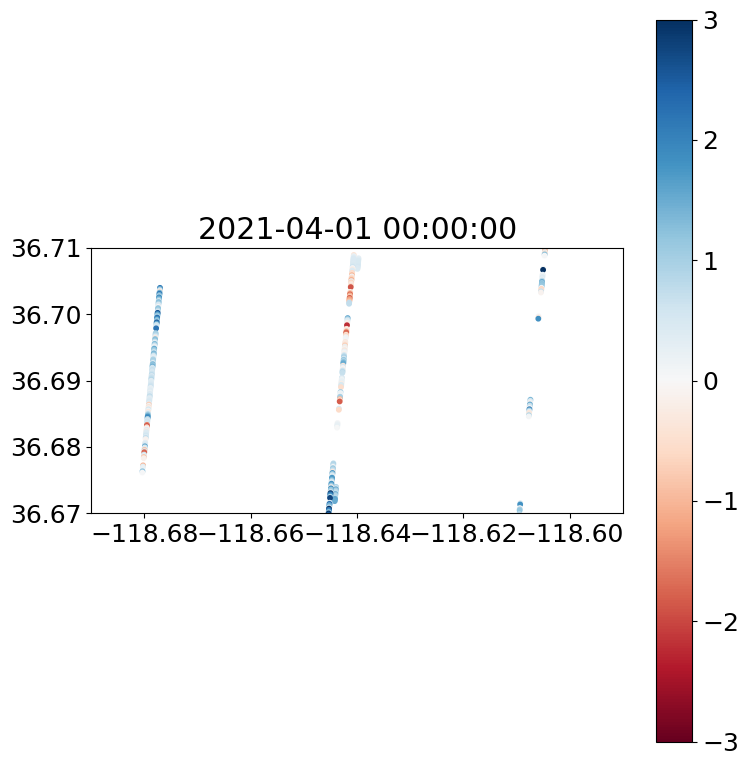

In [378]:
highlight_index = 1

fig, ax = plt.subplots(figsize=(8,8))

#sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=alt_highlight_dates[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
#dem_10.plot(ax=ax, cmap='Greys')
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[highlight_index]].plot(ax=ax, column='icesat2_3dep_dif',markersize=10, cmap='RdBu', 
                                                                                legend=True, vmin=-3, vmax=3) #edgecolor='k', linewidth=0.25, 
#ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{alt_highlight_dates[highlight_index]}')
ax.set_xlim(-118.69, -118.59)
ax.set_ylim(36.67, 36.71)

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

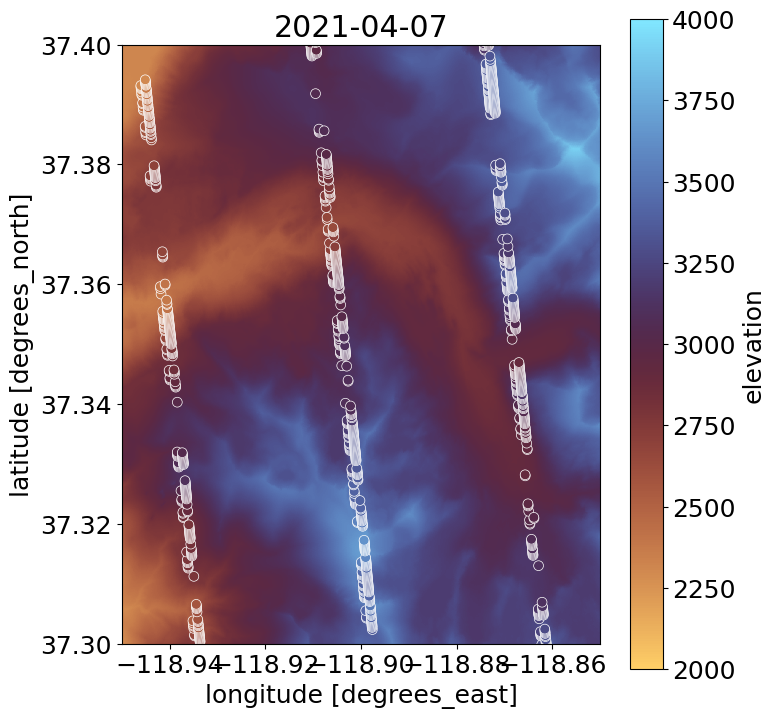

In [316]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(8,8))

#sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
dem_10.plot(ax=ax, cmap='managua', vmin=2000, vmax=4000)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates_dt[2]].plot(ax=ax, column='h_mean',markersize=50, cmap='managua', 
                                                                                edgecolor='white', linewidth=0.5, legend=False, vmin=2000, vmax=4000) # , vmin=-3, vmax=3
#ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{highlight_dates[highlight_index]}')
ax.set_xlim(-118.95, -118.85)
ax.set_ylim(37.3, 37.4)

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

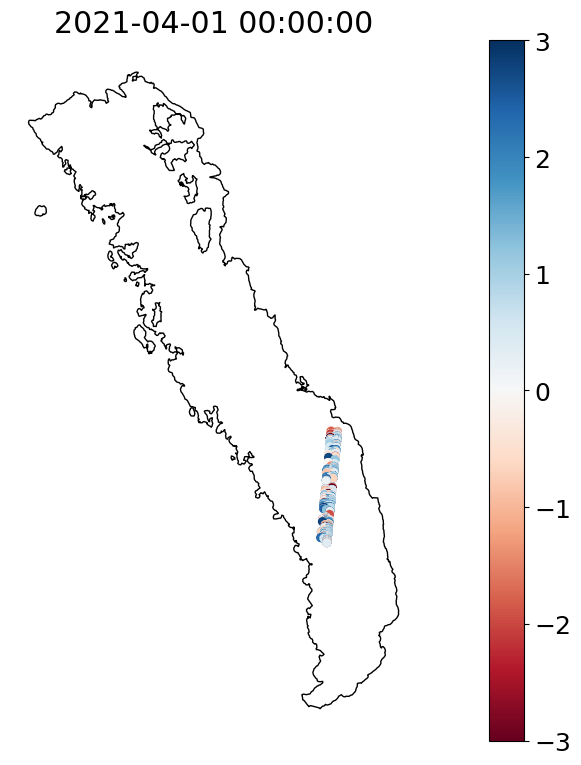

In [341]:
highlight_index = 2

fig, ax = plt.subplots(figsize=(15,8))

sierras.plot(ax=ax, facecolor='none', edgecolor='k')
#swe_sca_ds.SD_Post.sel(time=highlight_dates_dt[highlight_index]).rio.clip(sierras.geometry).plot(ax=ax, cmap='Blues', vmax=3)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight_dates[1]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
ax.set_axis_off()
ax.set_title('')
ax.set_title(f'{alt_highlight_dates[1]}')

plt.tight_layout()
#fig.savefig(f'../../figures/sierra_map_highlight_orange_{highlight_index}.png',dpi=300)

In [236]:
medians_both['reanalysis_sd'].max()

2.9326000213623047

### plot just median values, not boxplots in timeseries:

In [ ]:
atl06_medians = atl06sr_gdf[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()


In [ ]:
pos = (pd.to_datetime(atl06_medians.index) - pd.to_datetime(mpl_epoch)).days.values

In [ ]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def scatter_timeseries(df=None, col=None, groupby_col='acqdate', 
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', clim=(-2, 5)):
    # ATL06 stats
    if df is not None:
        #bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
        atl06_medians = df[[col, groupby_col]].dropna().groupby(groupby_col).median()

        #bp_stats_list = [i[0] for i in bp_stats.values]
        #bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
        #bp_alpha_boxes = bp_alpha/bp_alpha.max()
        pos = (pd.to_datetime(atl06_medians.index) - pd.to_datetime(mpl_epoch)).days.values
    
    boxplot_color = (31/255,119/255, 180/255, 0.3)
    
    f, ax = plt.subplots(figsize=(15,10))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')
    
    # Plot ATL06 data
    if df is not None:
        bxp_f = ax.scatter(y=atl06_medians[col].values, x=pos, c=boxplot_color)
    
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_xlabel('Date', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'../../figures/polished/{name}.jpeg', dpi=500)

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_93282/3845641289.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  bxp_f = ax.scatter(y=atl06_medians[col].values, x=pos, c=boxplot_color)


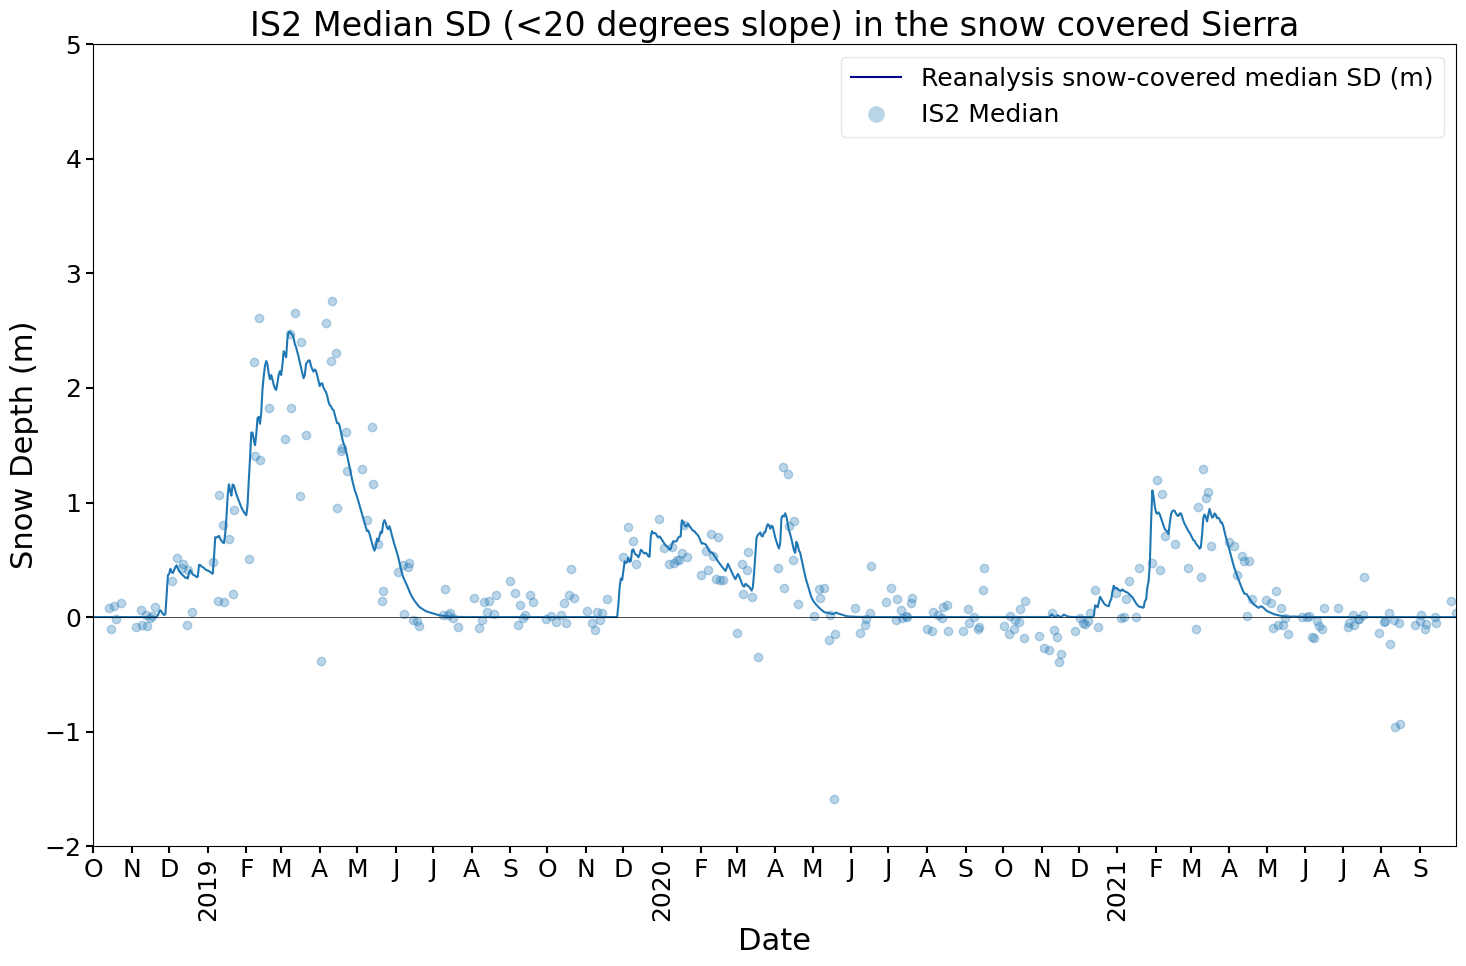

In [ ]:
#boxplot_color = (31/255,119/255, 180/255, 0.3)
custom = [Line2D([], [], linestyle='-', linewidth=1.5, color='darkblue'),
        #   Line2D([], [], linestyle='-', linewidth=1.5, color='lightgreen'),
           Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None')
          ]
          
          #Line2D([], [], linestyle='--', color='lightgrey')]
    
plt.rcParams['font.size'] = '18'
custom_labels = ['Reanalysis snow-covered median SD (m)', 'IS2 Median']

dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)
scatter_timeseries(atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope'] < 20)], col='icesat2_3dep_dif', title='IS2 Median SD (<20 degrees slope) in the snow covered Sierra')

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_93282/3845641289.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  bxp_f = ax.scatter(y=atl06_medians[col].values, x=pos, c=boxplot_color)


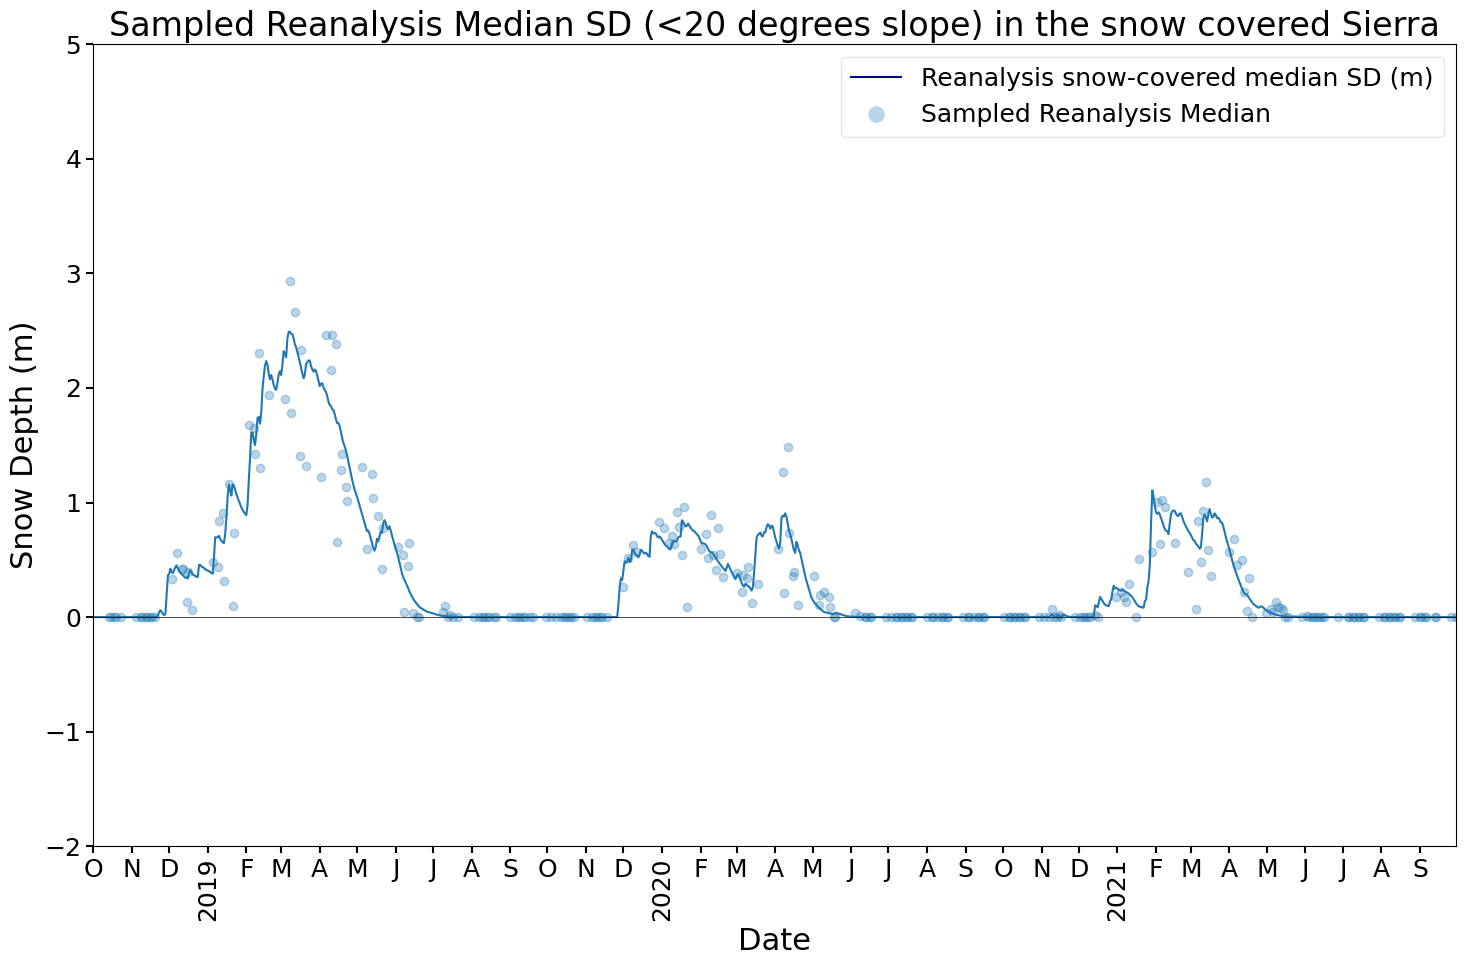

In [ ]:
#boxplot_color = (31/255,119/255, 180/255, 0.3)
custom = [Line2D([], [], linestyle='-', linewidth=1.5, color='darkblue'),
        #   Line2D([], [], linestyle='-', linewidth=1.5, color='lightgreen'),
           Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None')
          ]
          
          #Line2D([], [], linestyle='--', color='lightgrey')]
    
plt.rcParams['font.size'] = '18'
custom_labels = ['Reanalysis snow-covered median SD (m)', 'Sampled Reanalysis Median']

dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)
scatter_timeseries(atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope'] < 20)], col='reanalysis_sd', title='Sampled Reanalysis Median SD (<20 degrees slope) in the snow covered Sierra')

### Plot both sampled reanalysis and is2 together, and limit to dates with >30 or >100 data points:

In [40]:
# Function adapted from David Shean by Hannah Besso
# Allows for multiple levels of data to be plotted. Can just plot in situ snow depth, or can add any/all of the following:
# ICESat-2, sampled ASO, and full-site ASO

def scatter_timeseries_both(df=None, col1=None, col2=None, groupby_col='acqdate', 
                         title='Sierras Median Snow Depth', name='../figures/boxplots_cdec_aso.jpeg', clim=(-2, 5)):
    # ATL06 stats
    if col1 is not None:
        medians1 = df[[col1, groupby_col]].dropna().groupby(groupby_col).median()
        pos = (pd.to_datetime(medians1.index) - pd.to_datetime(mpl_epoch)).days.values
    
    if col2 is not None:
        medians2 = df[[col2, groupby_col]].dropna().groupby(groupby_col).median()
        pos = (pd.to_datetime(medians2.index) - pd.to_datetime(mpl_epoch)).days.values

    boxplot_color = (31/255,119/255, 180/255, 0.3)
    

    # Make the plot
    f, ax = plt.subplots(figsize=(15,10))
    
    median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')
    
    # Plot ATL06 data
    if col1 is not None:
        ax.scatter(y=medians1[col1].values, x=pos, c=boxplot_color)

    #Plot reanalysis data
    if col2 is not None:
        ax.scatter(y=medians2[col2].values, x=pos, c='orange', alpha=0.3)
    

    ax.set_title(title, fontsize=24)
    
    
    #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    #         patch.set_edgecolor('None')
    #         patch.set_linewidth(0)
    # if df is not None:
    #     for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    #         patch.set_color('k')  # or deeppink  
    
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Snow Depth (m)', fontsize=22)
    ax.set_xlabel('Date', fontsize=22)
    ax.set_ylim(*clim)
    ax.set_xlim([dt_min_plot, dt_max_plot])
    
    
    # X AXIS LABELS     
    months = mdates.MonthLocator()
    month_fmt = mdates.DateFormatter('%b')
    
    def m_fmt(x, pos=None):
        return month_fmt(x)[0]
    
    ax.xaxis.set_minor_locator(months) 
    ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
    
    years = mdates.MonthLocator(bymonth=1)
    ax.format_xdata = mdates.DateFormatter('%Y')
    years_fmt = mdates.DateFormatter('%Y')
    ax.xaxis.set_major_locator(years)
    ax.xaxis.set_major_formatter(years_fmt)
    ax.tick_params('both', length=5, width=1.5, which='major')
    ax.tick_params('both', length=5, width=1.5, which='minor')
    
    ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10
    
    for label in ax.get_xticklabels(which='major'): #
        label.set(rotation=90, horizontalalignment='center')
    
    plt.tight_layout()
    #plt.savefig(f'../../figures/polished/{name}.jpeg', dpi=500)

In [ ]:
atl06sr_snowy_20slope = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope'] < 20)]

In [ ]:
atl06sr_snowy_20slope['n'] = atl06sr_snowy_20slope.groupby('acqdate')['acqdate'].transform('count')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_5849/3942210046.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(y=medians1[col1].values, x=pos, c=boxplot_color)


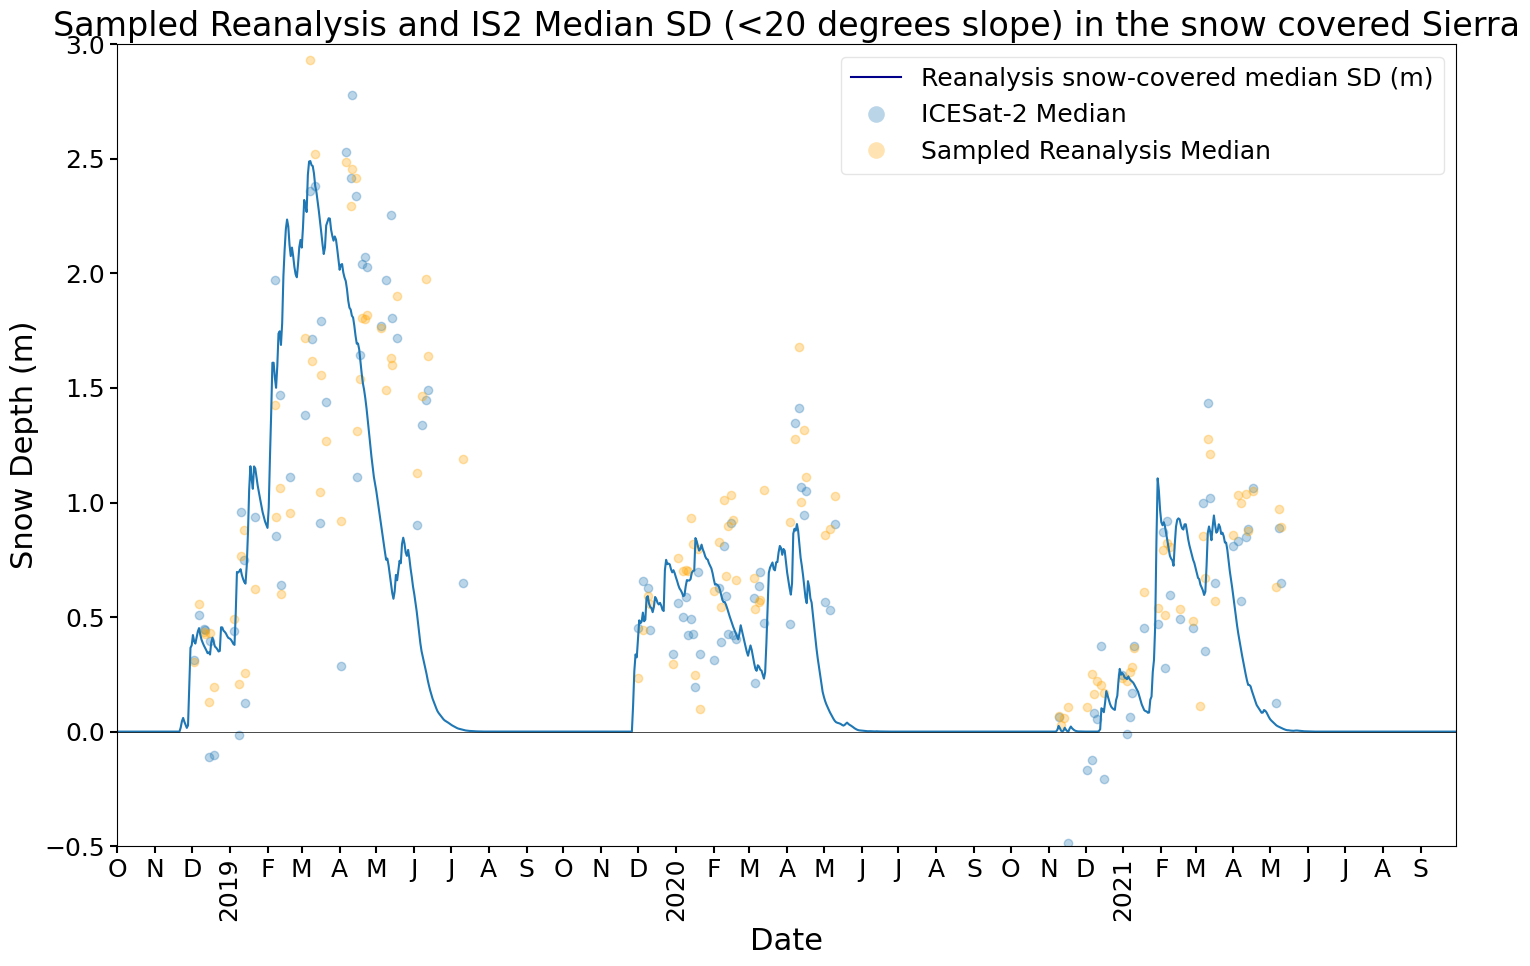

In [41]:
boxplot_color = (31/255,119/255, 180/255, 0.3)
custom = [Line2D([], [], linestyle='-', linewidth=1.5, color='darkblue'),
          Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None'),
          Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color='orange',alpha=0.3, linestyle='None')
          ]


plt.rcParams['font.size'] = '18'
custom_labels = ['Reanalysis snow-covered median SD (m)', 'ICESat-2 Median', 'Sampled Reanalysis Median']

dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

scatter_timeseries_both(df = atl06sr_gdf_fsca_9[atl06sr_gdf_fsca_9['n'] > 100], 
                        col1 = 'icesat2_3dep_dif', 
                        col2 = 'reanalysis_sd',
                        title='Sampled Reanalysis and IS2 Median SD (<20 degrees slope) in the snow covered Sierra',
                        clim=[-0.5, 3])

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_13814/3942210046.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(y=medians1[col1].values, x=pos, c=boxplot_color)


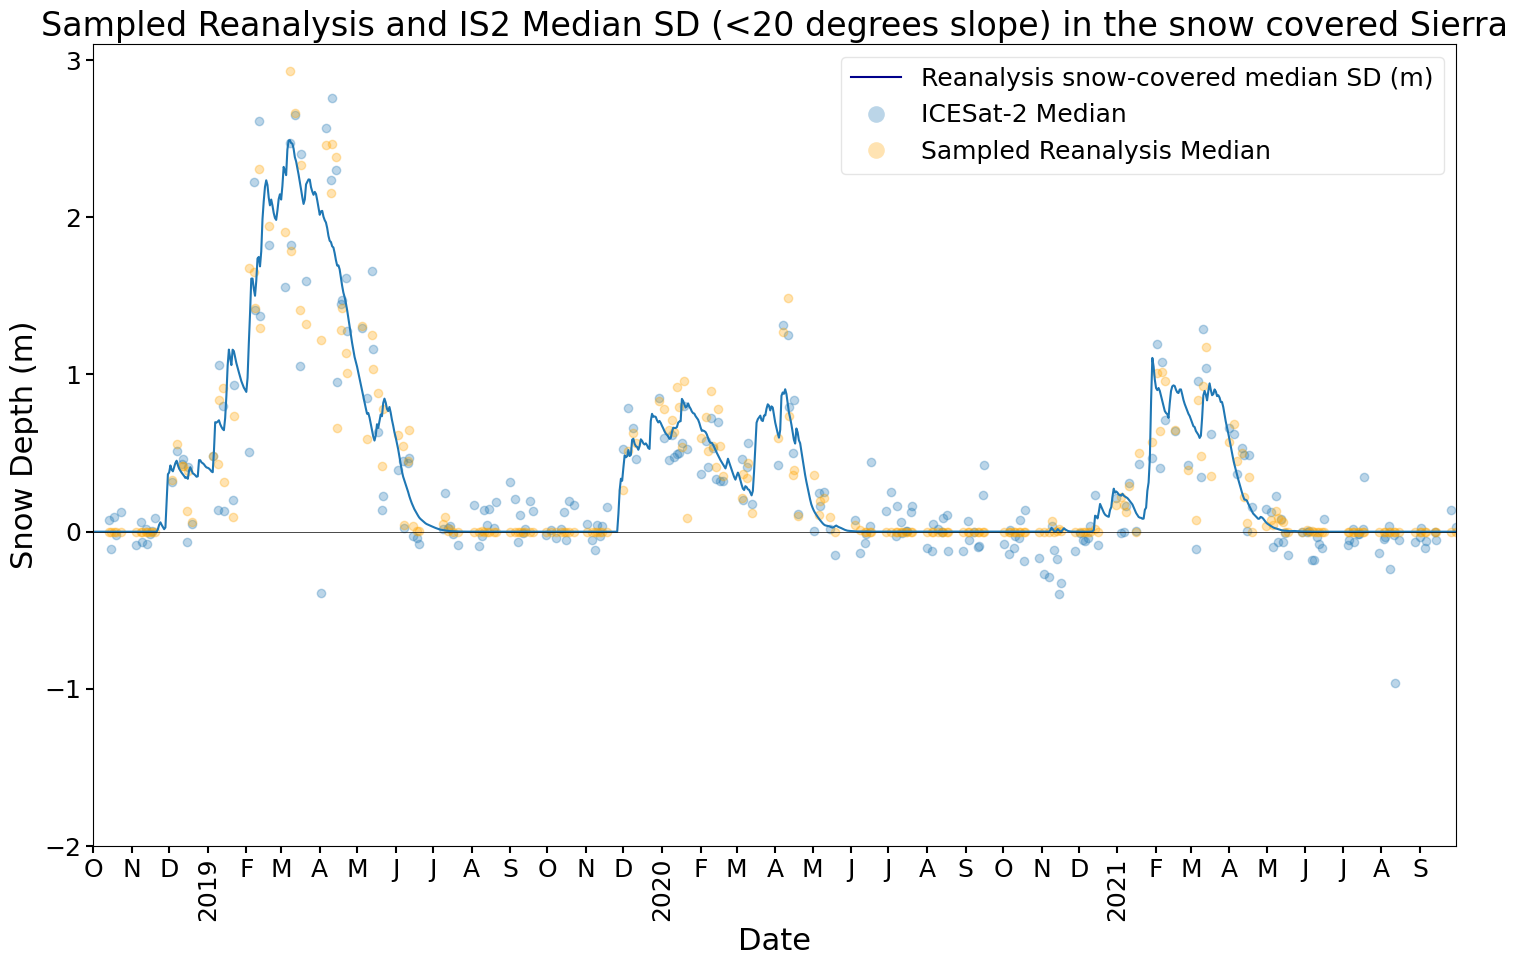

In [ ]:
boxplot_color = (31/255,119/255, 180/255, 0.3)
custom = [Line2D([], [], linestyle='-', linewidth=1.5, color='darkblue'),
          Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None'),
          Line2D([], [], marker='o', markersize=12, markeredgecolor='none', color='orange',alpha=0.3, linestyle='None')
          ]


plt.rcParams['font.size'] = '18'
custom_labels = ['Reanalysis snow-covered median SD (m)', 'ICESat-2 Median', 'Sampled Reanalysis Median']

dt_min_plot = datetime.date(2018, 10, 1)
dt_max_plot = datetime.date(2021, 9, 30)

scatter_timeseries_both(df = atl06sr_snowy_20slope[atl06sr_snowy_20slope['n'] > 30], 
                        col1 = 'icesat2_3dep_dif', 
                        col2 = 'reanalysis_sd',
                        title='Sampled Reanalysis and IS2 Median SD (<20 degrees slope) in the snow covered Sierra',
                        clim=[-2, 3.1])

### Calculate the residuals between the acquisition date medians and the overall medians on the same dates:

In [138]:
atl06sr_medians_snowy_20slope = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope'] < 20), ['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()

In [139]:
reanalysis_medians_snowy_20slope = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope'] < 20), ['reanalysis_sd', 'acqdate']].dropna().groupby('acqdate').median()

In [159]:
# residuals = pd.DataFrame(index=atl06sr_medians_snowy_20slope.index)
# residuals['atl06sr'] = np.nan
# residuals['reanalysis'] = np.nan

# for date in atl06sr_medians_snowy_20slope.index:
#     residuals.loc[date, 'atl06sr'] = atl06sr_medians_snowy_20slope.loc[date, 'icesat2_3dep_dif'] - median_sd.SD_Post.sel(time=pd.to_datetime(date))
#     residuals.loc[date, 'reanalysis'] = reanalysis_medians_snowy_20slope.loc[date, 'reanalysis_sd'] - median_sd.SD_Post.sel(time=pd.to_datetime(date))
#     print(date)

2018-10-14
2018-10-15
2018-10-18
2018-10-19
2018-10-23
2018-11-04
2018-11-08
2018-11-09
2018-11-12
2018-11-13
2018-11-16
2018-11-17
2018-11-20
2018-12-03
2018-12-07
2018-12-11
2018-12-12
2018-12-15
2018-12-16
2018-12-19
2019-01-05
2019-01-09
2019-01-10
2019-01-13
2019-01-14
2019-01-18
2019-01-21
2019-01-22
2019-02-03
2019-02-07
2019-02-08
2019-02-11
2019-02-12
2019-02-19
2019-03-04
2019-03-08
2019-03-09
2019-03-12
2019-03-16
2019-03-17
2019-03-21
2019-04-02
2019-04-06
2019-04-10
2019-04-11
2019-04-14
2019-04-15
2019-04-18
2019-04-19
2019-04-22
2019-04-23
2019-05-05
2019-05-09
2019-05-13
2019-05-14
2019-05-18
2019-05-21
2019-05-22
2019-06-03
2019-06-07
2019-06-08
2019-06-11
2019-06-12
2019-06-15
2019-06-18
2019-06-20
2019-07-09
2019-07-11
2019-07-13
2019-07-15
2019-07-17
2019-07-21
2019-08-03
2019-08-07
2019-08-09
2019-08-11
2019-08-13
2019-08-15
2019-08-19
2019-08-21
2019-09-01
2019-09-05
2019-09-07
2019-09-09
2019-09-11
2019-09-13
2019-09-17
2019-09-19
2019-09-30
2019-10-04
2019-10-08

In [76]:
# snow_on_dates = median_sd.time.where(median_sd.SD_Post != 0).dropna('time')

In [78]:
# residuals['snow_presence'] = 0

# for day in snow_on_dates.values:
#     # Convert to Python datetime object
#     py_datetime = day.astype('M8[ms]').astype(datetime.datetime)
#     py_date = py_datetime.date()

#     if py_date in residuals.index:
#         residuals.loc[py_date, 'snow_presence'] = 1
#     else:
#         continue

In [79]:
# residuals['residuals_diff'] = residuals['atl06sr'] - residuals['reanalysis']

In [80]:
# residuals

,atl06sr,reanalysis,snow_presence,residuals_diff
acqdate,,,,
2018-10-14,0.075891,0.0,0,0.075891
2018-10-15,-0.108008,0.0,0,-0.108008
2018-10-18,0.093040,0.0,0,0.093040
2018-10-19,-0.018844,0.0,0,-0.018844
2018-10-23,0.122762,0.0,0,0.122762
...,...,...,...,...
2021-09-06,-0.059516,0.0,0,-0.059516
2021-09-13,-0.000564,0.0,0,-0.000564
2021-09-14,-0.055093,0.0,0,-0.055093


In [81]:
# residuals.to_pickle('../../data/results/sierras_sd_residuals.pkl')

In [61]:
residuals = pd.read_pickle('../../data/results/sierras_sd_residuals.pkl')

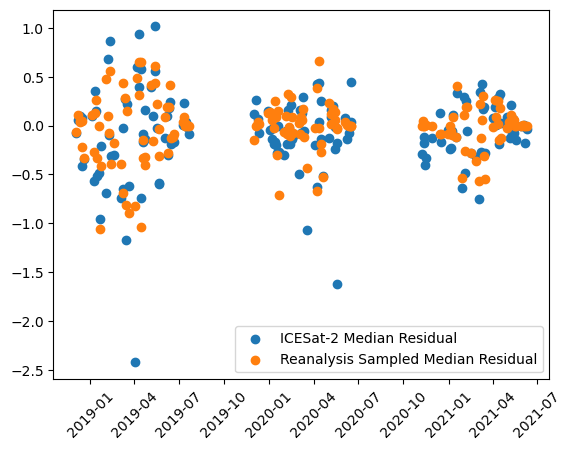

In [82]:
fig, ax = plt.subplots()
residuals_subset = residuals[residuals['snow_presence'] == 1]

ax.scatter(residuals_subset.index, residuals_subset['atl06sr'], label='ICESat-2 Median Residual', marker='o')
ax.scatter(residuals_subset.index, residuals_subset['reanalysis'], label='Reanalysis Sampled Median Residual', marker='o')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

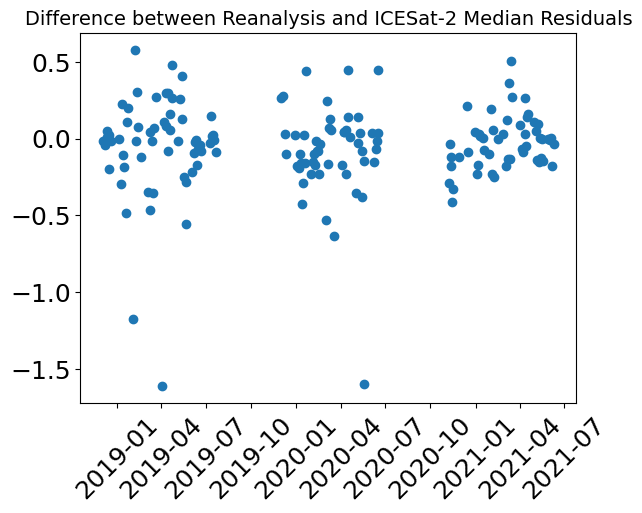

In [210]:
fig, ax = plt.subplots()
residuals_subset = residuals[residuals['snow_presence'] == 1]

ax.scatter(residuals_subset.index, residuals_subset['residuals_diff'], label='Difference between reanalysis and is2 residuals', marker='o')
#ax.legend()
ax.set_title('Difference between Reanalysis and ICESat-2 Median Residuals',fontsize=14)
ax.tick_params(axis='x', labelrotation=45)

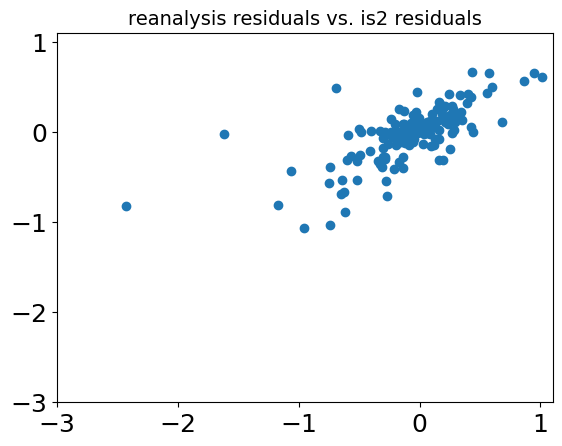

In [215]:
fig, ax = plt.subplots()
ax.scatter(residuals_subset['atl06sr'], residuals_subset['reanalysis'], marker='o')
ax.set_title('reanalysis residuals vs. is2 residuals', fontsize=14)
ax.set_ybound(-3,1.1)
ax.set_xbound(-3,1.1)

In [84]:
residuals_subset['residuals_diff'].describe()

count    163.000000
mean      -0.050966
std        0.283740
min       -1.606707
25%       -0.154470
50%       -0.016483
75%        0.063806
max        0.577667
Name: residuals_diff, dtype: float64

In [151]:
date = atl06sr_medians_snowy_20slope.index[0]
#date_xr = pd.to_datetime(atl06sr_medians_snowy_20slope.index[0])
atl06sr_medians_snowy_20slope.loc[date, 'icesat2_3dep_dif'] - median_sd.SD_Post.sel(time=pd.to_datetime(date)).values
#median_sd.SD_Post.sel(time=date)

np.float64(0.07589105893862325)

In [158]:
date = atl06sr_medians_snowy_20slope.index[0]
#date_xr = pd.to_datetime(atl06sr_medians_snowy_20slope.index[0])
residual_try = atl06sr_medians_snowy_20slope.loc[date, 'icesat2_3dep_dif'] - median_sd.SD_Post.sel(time=pd.to_datetime(date))
residual_try

<xarray.DataArray 'SD_Post' ()> Size: 8B
dask.array<subtract, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    time         datetime64[ns] 8B 2018-10-14
    spatial_ref  int64 8B 0

In [150]:
median_sd.SD_Post['time']

<xarray.DataArray 'time' (time: 1096)> Size: 9kB
array(['2018-10-01T00:00:00.000000000', '2018-10-02T00:00:00.000000000',
       '2018-10-03T00:00:00.000000000', ..., '2021-09-28T00:00:00.000000000',
       '2021-09-29T00:00:00.000000000', '2021-09-30T00:00:00.000000000'],
      shape=(1096,), dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0

### Subset by various factors, and remove dates with limited data availability:  
The result is that data availability is generally quite good - limiting by 30n only removes a few acquisition dates, and even upping that threshold to 100 only removes like 5 dates.

In [17]:
atl06sr_gdf['n'] = atl06sr_gdf.groupby('acqdate')['acqdate'].transform('count')

In [25]:
atl06sr_gdf_slope20 = atl06sr_gdf[atl06sr_gdf['slope'] < 20]
atl06sr_gdf_slope20['n'] = atl06sr_gdf_slope20.groupby('acqdate')['acqdate'].transform('count')

atl06sr_gdf_slope20_30n = atl06sr_gdf_slope20[atl06sr_gdf_slope20['n'] > 30]
atl06sr_gdf_slope20_100n = atl06sr_gdf_slope20[atl06sr_gdf_slope20['n'] > 100]

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [21]:
atl06sr_gdf_snowarea = atl06sr_gdf[atl06sr_gdf['mask']==1]
atl06sr_gdf_snowy_slope20 = atl06sr_gdf_snowarea[atl06sr_gdf_snowarea['slope'] < 20]
atl06sr_gdf_snowy_slope20['n'] = atl06sr_gdf_snowy_slope20.groupby('acqdate')['acqdate'].transform('count')

atl06sr_gdf_snowy_slope20_30n = atl06sr_gdf_snowy_slope20[atl06sr_gdf_snowy_slope20['n'] > 30]
atl06sr_gdf_snowy_slope20_100n = atl06sr_gdf_snowy_slope20[atl06sr_gdf_snowy_slope20['n'] > 100]

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [22]:
len(atl06sr_gdf['acqdate'].unique())

329

In [104]:
len(atl06sr_gdf_30['acqdate'].unique())

324

In [26]:
len(atl06sr_gdf_slope20_30n['acqdate'].unique())

324

In [27]:
len(atl06sr_gdf_snowy_slope20_30n['acqdate'].unique())

271

In [29]:
len(atl06sr_gdf_snowy_slope20_100n['acqdate'].unique())


260

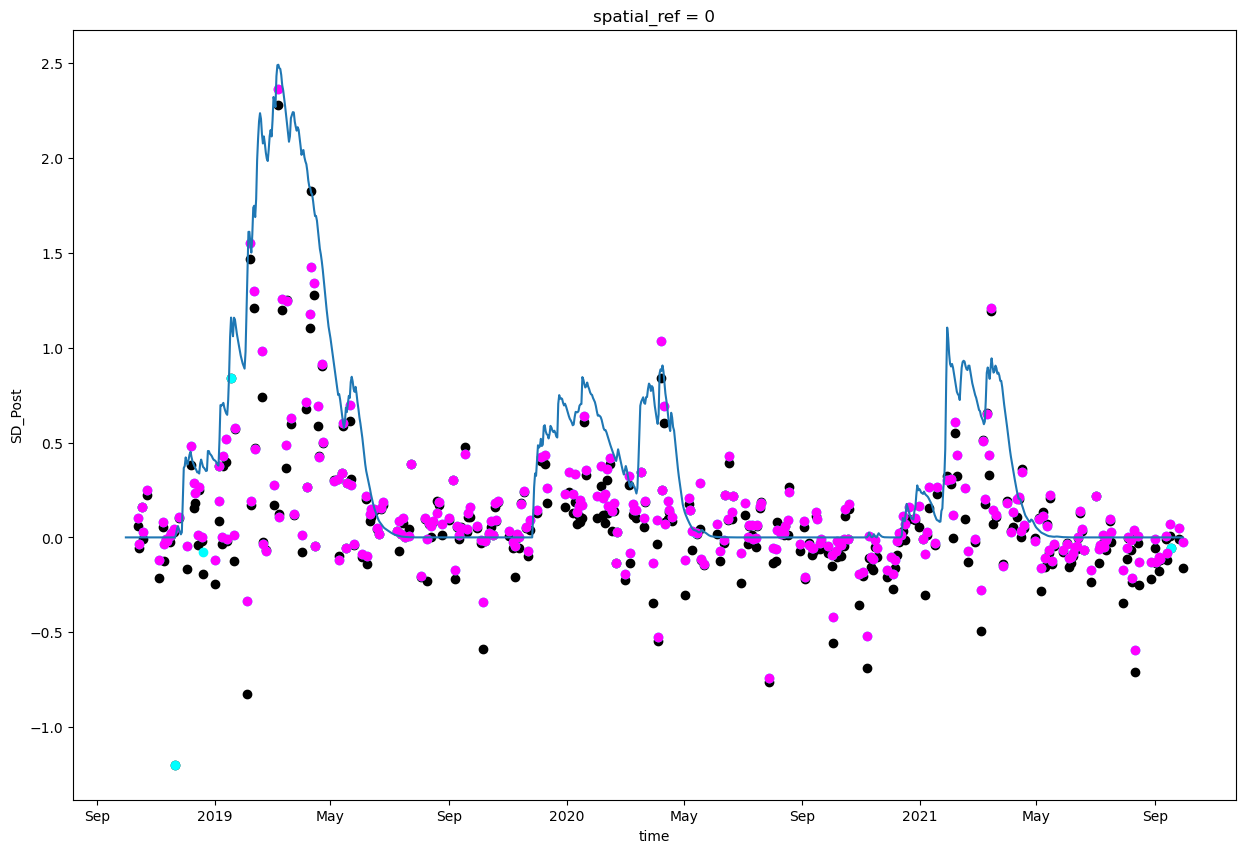

In [35]:
atl06_medians = atl06sr_gdf[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos = (pd.to_datetime(atl06_medians.index) - pd.to_datetime(mpl_epoch)).days.values

atl06_slope20_medians = atl06sr_gdf_slope20[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_slope20 = (pd.to_datetime(atl06_slope20_medians.index) - pd.to_datetime(mpl_epoch)).days.values

atl06_slope20_30n_medians = atl06sr_gdf_slope20_30n[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_slope20_30n = (pd.to_datetime(atl06_slope20_30n_medians.index) - pd.to_datetime(mpl_epoch)).days.values



f, ax = plt.subplots(figsize=(15,10))
    
median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')

# Plot ATL06 data

ax.scatter(y=atl06_medians['icesat2_3dep_dif'].values, x=pos, c='k')
ax.scatter(y=atl06_slope20_medians['icesat2_3dep_dif'].values, x=pos_slope20, c='cyan')
ax.scatter(y=atl06_slope20_30n_medians['icesat2_3dep_dif'].values, x=pos_slope20_30n, c='magenta')

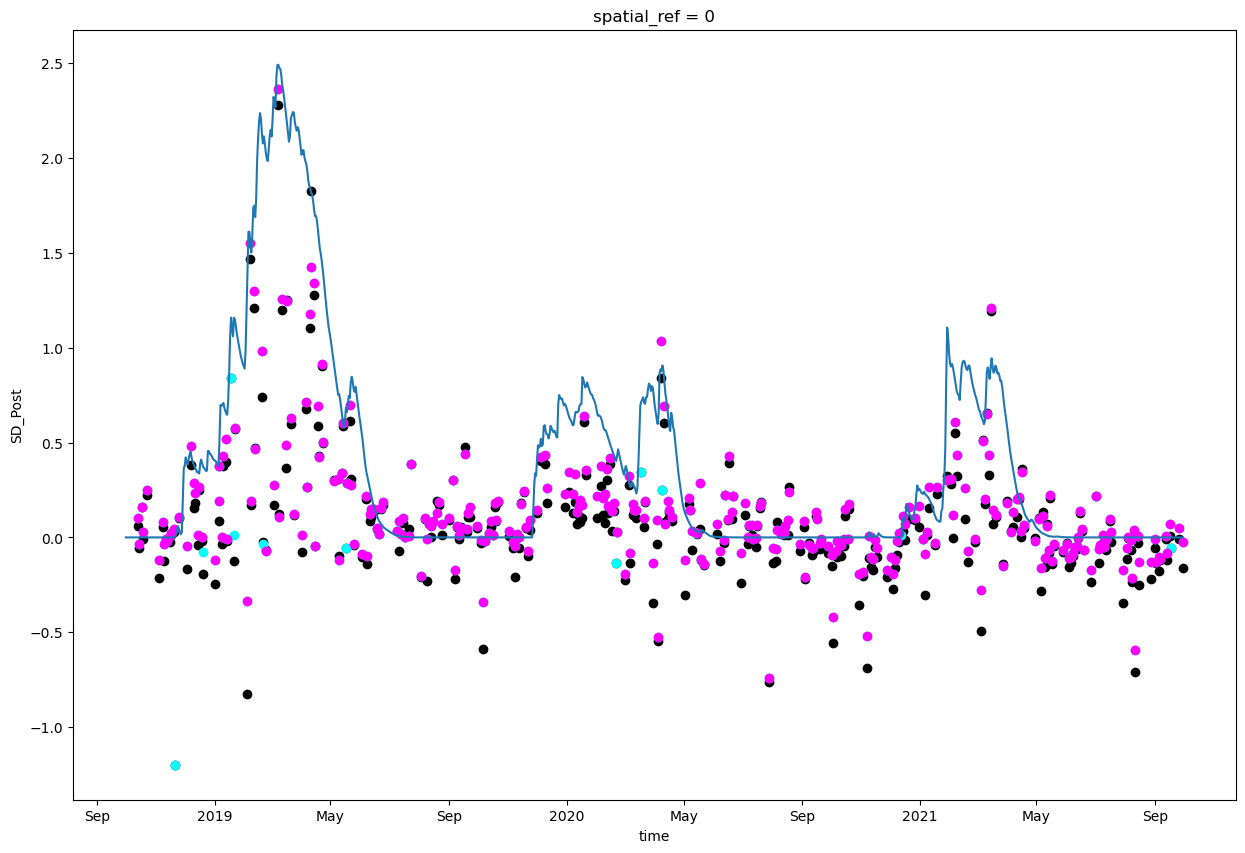

In [36]:
atl06_slope20_medians = atl06sr_gdf_slope20[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_slope20 = (pd.to_datetime(atl06_slope20_medians.index) - pd.to_datetime(mpl_epoch)).days.values

atl06_slope20_100n_medians = atl06sr_gdf_slope20_100n[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_slope20_100n = (pd.to_datetime(atl06_slope20_100n_medians.index) - pd.to_datetime(mpl_epoch)).days.values



f, ax = plt.subplots(figsize=(15,10))
    
median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')

# Plot ATL06 data

ax.scatter(y=atl06_medians['icesat2_3dep_dif'].values, x=pos, c='k')
ax.scatter(y=atl06_slope20_medians['icesat2_3dep_dif'].values, x=pos_slope20, c='cyan')
ax.scatter(y=atl06_slope20_100n_medians['icesat2_3dep_dif'].values, x=pos_slope20_100n, c='magenta')

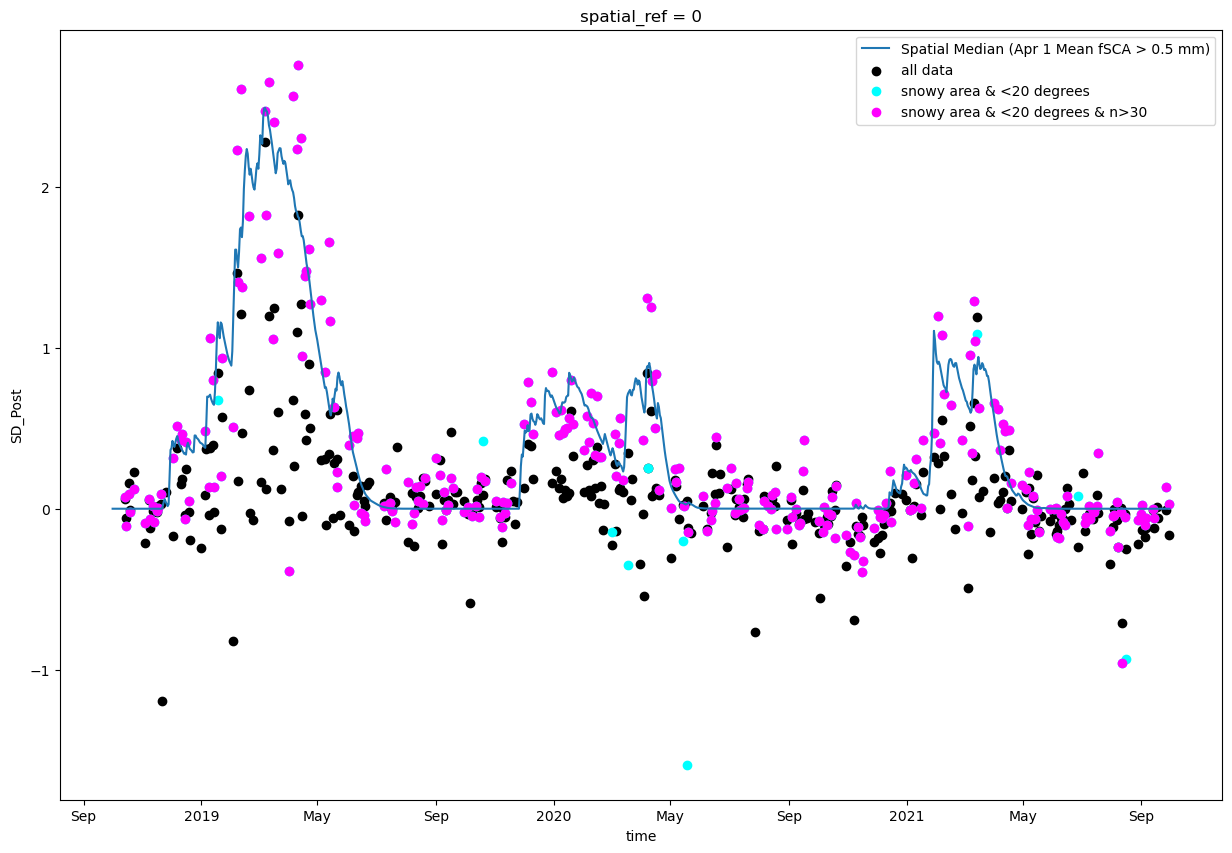

In [37]:
atl06sr_gdf_snowy_slope20_medians = atl06sr_gdf_snowy_slope20[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_snowy_slope20 = (pd.to_datetime(atl06sr_gdf_snowy_slope20_medians.index) - pd.to_datetime(mpl_epoch)).days.values

atl06sr_gdf_snowy_slope20_30n_medians = atl06sr_gdf_snowy_slope20_30n[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_snowy_slope20_30n = (pd.to_datetime(atl06sr_gdf_snowy_slope20_30n_medians.index) - pd.to_datetime(mpl_epoch)).days.values



f, ax = plt.subplots(figsize=(15,10))
    
median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')

# Plot ATL06 data

ax.scatter(y=atl06_medians['icesat2_3dep_dif'].values, x=pos, c='k', label='all data')
ax.scatter(y=atl06sr_gdf_snowy_slope20_medians['icesat2_3dep_dif'].values, x=pos_snowy_slope20, c='cyan', label='snowy area & <20 degrees')
ax.scatter(y=atl06sr_gdf_snowy_slope20_30n_medians['icesat2_3dep_dif'].values, x=pos_snowy_slope20_30n, c='magenta', label='snowy area & <20 degrees & n>30')
ax.legend()

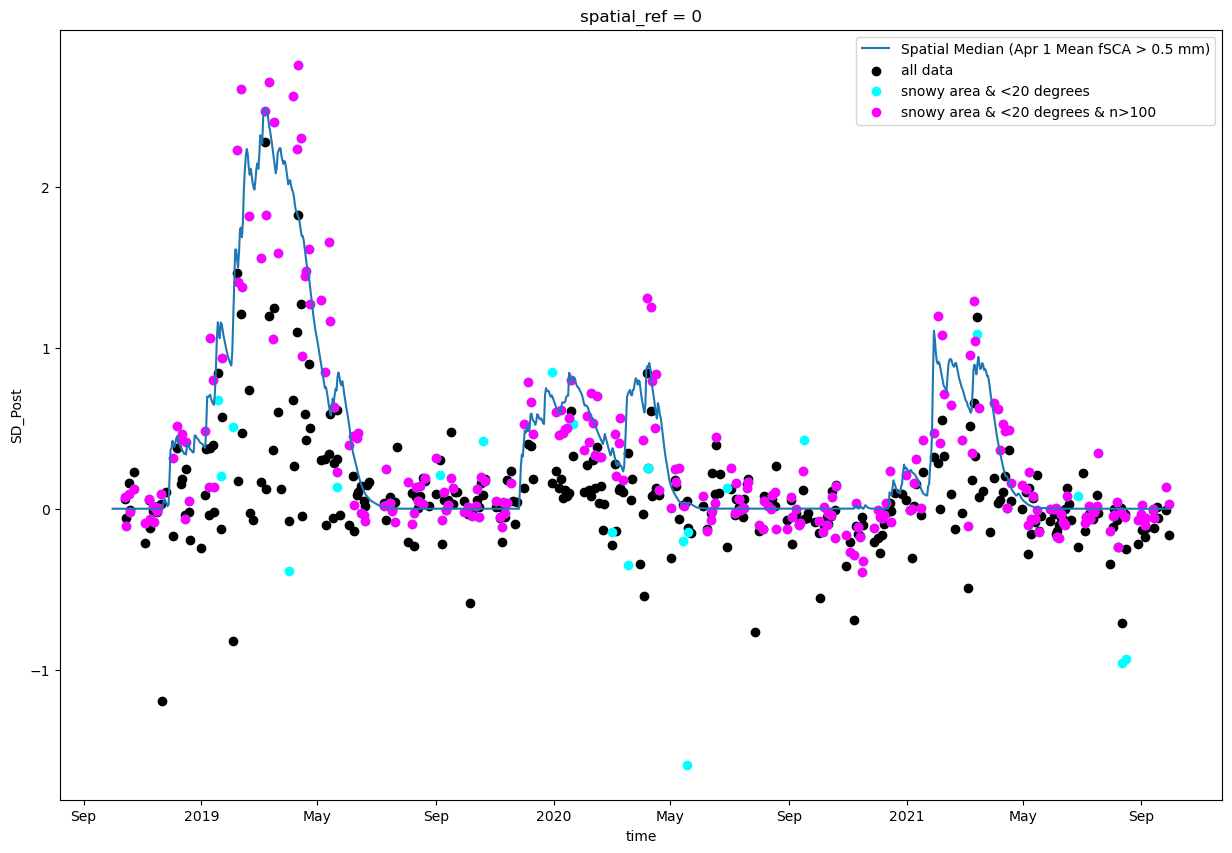

In [38]:
atl06sr_gdf_snowy_slope20_medians = atl06sr_gdf_snowy_slope20[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_snowy_slope20 = (pd.to_datetime(atl06sr_gdf_snowy_slope20_medians.index) - pd.to_datetime(mpl_epoch)).days.values

atl06sr_gdf_snowy_slope20_100n_medians = atl06sr_gdf_snowy_slope20_100n[['icesat2_3dep_dif', 'acqdate']].dropna().groupby('acqdate').median()
pos_snowy_slope20_100n = (pd.to_datetime(atl06sr_gdf_snowy_slope20_100n_medians.index) - pd.to_datetime(mpl_epoch)).days.values



f, ax = plt.subplots(figsize=(15,10))
    
median_sd.SD_Post.plot(label='Spatial Median (Apr 1 Mean fSCA > 0.5 mm)')

# Plot ATL06 data

ax.scatter(y=atl06_medians['icesat2_3dep_dif'].values, x=pos, c='k', label='all data')
ax.scatter(y=atl06sr_gdf_snowy_slope20_medians['icesat2_3dep_dif'].values, x=pos_snowy_slope20, c='cyan', label='snowy area & <20 degrees')
ax.scatter(y=atl06sr_gdf_snowy_slope20_100n_medians['icesat2_3dep_dif'].values, x=pos_snowy_slope20_100n, c='magenta', label='snowy area & <20 degrees & n>100')
ax.legend()